# Naive Bayes Classifier for Fake News Recognition

### Advanced Statistics for Physics Analysis

* Hooman Sabzi - 2119061
* Franco Aquistapace Tagua - 2106651
* Daize Li - 2106187

Fake news are defined by the New York Times as "a made-up story with an intention to deceive", with the intent to confuse or deceive people. They are everywhere in our daily life, and come especially from social media platforms and applications in the online world. Being able to distinguish fake contents form real news is today one of the most serious challenges facing the news industry. Naive Bayes classifiers [1] are powerful algorithms that are used for text data analysis and are connected to classification t sks of text in multiple classes. The goal of the project is to implement a Multinomial Naive Bayes classifier in R and test its performances in the classification of social media posts. The suggested data set is available on Kaggle [2]. Possible suggested lables for classifying the text are the following:

* **True** - 5
* **Not-Known** - 4
* **Mostly-True** - 3
* **Half-True** - 2
* **False** - 1
* **Barely-True** - 0

The Kaggle dataset \[2] consists of:

* **Training set**: 10,240 instances
* **Test set**: 1,267 instances

## Project Tasks

1. **Divide the dataset** into training, validation, and testing sets
2. **Tokenize** each word (convert uppercase to lowercase, then split into tokens)
3. **Clean the data** by removing stop words
4. **Perform token normalization**: create equivalence classes to map similar tokens to the same class
5. **Build the vocabulary** and perform feature selection
6. **Train and evaluate** the Naive Bayes classifier
7. **Show the results** using appropriate metrics and visualizations

## Additional Task

Apply the developed methods and techniques to a second dataset \[3], which is a binary classification task with the following labels:

* **1** $\rightarrow$ *Unreliable*
* **0** $\rightarrow$ *Reliable*

## Final Goal

Compare and analyze the performance of the Naive Bayes classifier on the two datasets and draw conclusions from the results.

---

### Bibliography

\[1] C. D. Manning, *Chapter 13, Text Classification and Naive Bayes*, in *Introduction to Information Retrieval*, Cambridge University Press, 2008.

\[2] [Fake News Content Detection Dataset – Kaggle](https://www.kaggle.com/datasets/anmolkumar/fake-news-content-detection?select=train.csv)

\[3] [Fake News Classification(A Comprehensive Dataset for Fake News Detection) – Kaggle](https://www.kaggle.com/datasets/aadyasingh55/fake-news-classification)

---

## Theoretical Background

We use **Bayes’ Theorem** to infer the posterior probability of a label given the title of a news article. Suppose we are given a **news title**, and we want to predict its **label**:

$$
P(\text{label} \mid \text{title}, I) = \frac{P(\text{title} \mid \text{label}, I) \cdot P(\text{label} \mid I)}{P(\text{title} \mid I)}
$$

Where:

* $P(\text{label} \mid \text{title}, I)$ is the **posterior** probability of the label given the title.
* $P(\text{title} \mid \text{label}, I)$ is the **likelihood** of observing the title given the label.
* $P(\text{label} \mid I)$ is the **prior** probability of the label.
* $P(\text{title} \mid I)$ is the **evidence**, which serves as a normalization constant and can be ignored during classification.

---

In general, let there be $m$ possible label categories. To classify a title, we compute the posterior probability for each label:

$$
P(\text{label}_i \mid \text{title}, I), \quad \text{for } i = 1, 2, \ldots, m
$$

The predicted label is the one with the **highest posterior probability**:

$$
\text{Predicted label} = \arg\max_{i} P(\text{label}_i \mid \text{title}, I)
$$

* If $m = 2$, the classifier is called a **Binomial Naive Bayes Classifier**.
* If $m > 2$, it is a **Multinomial Naive Bayes Classifier**.

---

### The Naive Assumption

To compute the likelihood $P(\text{title} \mid \text{label}_i, I)$, we make a simplifying **naive assumption**:
If the title contains $n$ words: $\text{word}_1, \text{word}_2, \ldots, \text{word}_n$, we assume the words are conditionally independent given the label.

Thus:

$$
P(\text{title} \mid \text{label}_i, I) = \prod_{j=1}^{n} P(\text{word}_j \mid \text{label}_i)
$$

This assumption makes the model **naive**, as it ignores any correlation or dependency between words in the same title.

---

### Choosing the Prior

The prior $P(\text{label}_i \mid I)$ can be estimated from the training data as the relative frequency of each label:

$$
P(\text{label}_i \mid I) = \frac{\text{Number of titles with label } i}{\text{Total number of titles}}
$$

---

### Final Classification Rule

Putting it all together, the predicted label for a given title is:

$$
\text{label}_p = \arg\max_{i} \left[ P(\text{label}_i \mid I) \cdot \prod_{j=1}^{n} P(\text{word}_j \mid \text{label}_i) \right]
$$

This is the fundamental principle behind the **Multinomial Naive Bayes Classifier** for text classification tasks.

---

In [54]:
# Load required libraries
library(tm)
library(dplyr)
library(tidyr)
library(tidyr)
library(caret)
library(forcats)
library(ggplot2)
library(stringr)
library(stringr)
library(textstem)
library(tidytext)
library(textstem)
library(tidyverse)
library(stopwords)
library(SnowballC)
library(patchwork)

# set plot size in Jupyter or other environments
options(repr.plot.width = 20, repr.plot.height = 8)

## The Datasets

We are working with two datasets related to fake news detection. One dataset `Fake_News_Content_Detection` is clean and properly formatted, while the other `Fake_News_Classification` is improperly formatted with all data in one column.

### Reading the csv files

In [3]:
# Load Multi-class dataset (clean)
trainData1 <- read.csv("./Data/train.csv")

# Load Binary-class dataset (with formatting issues)
rawData <- read_csv("./Data/evaluation.csv")

Warning message:
"One or more parsing issues, call `problems()` on your data frame for details, e.g.:
  dat <- vroom(...)
  problems(dat)"
Rows: 11853 Columns: 1
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (1): ;title;text;label

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


### Cleaning the raw data

In [4]:
# combine Columns into one
dfCombined <- rawData %>%
  unite("combined", everything(), sep = " ", remove = FALSE) %>%
  select(combined)

In [5]:
# Separate the combined column using ';' into expected fields
trainData2 <- dfCombined %>%
  separate(
    col = combined,
    into = c("Num", "Text_Tag", "Text", "Labels"),
    sep = ";",
    extra = "merge",  # Merge overflow fields into the last column
    fill = "right",   # Fill missing fields with NA on the right
    remove = TRUE     # Drop the original 'combined' column
  )

In [6]:
# Keep only rows with valid binary Labels (0 or 1)
trainData2 <- trainData2[trainData2$Labels %in% c(0, 1), ]

# Convert Labels to numeric type
trainData2$Labels <- as.numeric(trainData2$Labels)

# Drop the 'Num' column (it's just an index)
trainData2 <- trainData2[, !names(trainData2) %in% c("Num")]

# Reorder columns for clarity
trainData2 <- trainData2[, c("Labels", "Text", "Text_Tag")]

# Remove entries where the text is too short to be meaningful
trainData2 <- trainData2[nchar(trainData2$Text) > 20, ]

### Checking the columns

In [7]:
cat("Multi-class dataset columns:\n", paste(colnames(trainData1), collapse = ", "), "\n\n")
cat("Binary-class dataset columns:\n", paste(colnames(trainData2), collapse = ", "), "\n")

Multi-class dataset columns:
 Labels, Text, Text_Tag 

Binary-class dataset columns:
 Labels, Text, Text_Tag 


### Number of samples

In [8]:
cat("Number of Multi-class samples:", nrow(trainData1), "\n")
cat("Number of Binary-class samples:", nrow(trainData2), "\n")

Number of Multi-class samples: 10240 
Number of Binary-class samples: 7235 


### Visualize Class Distribution in Data sets

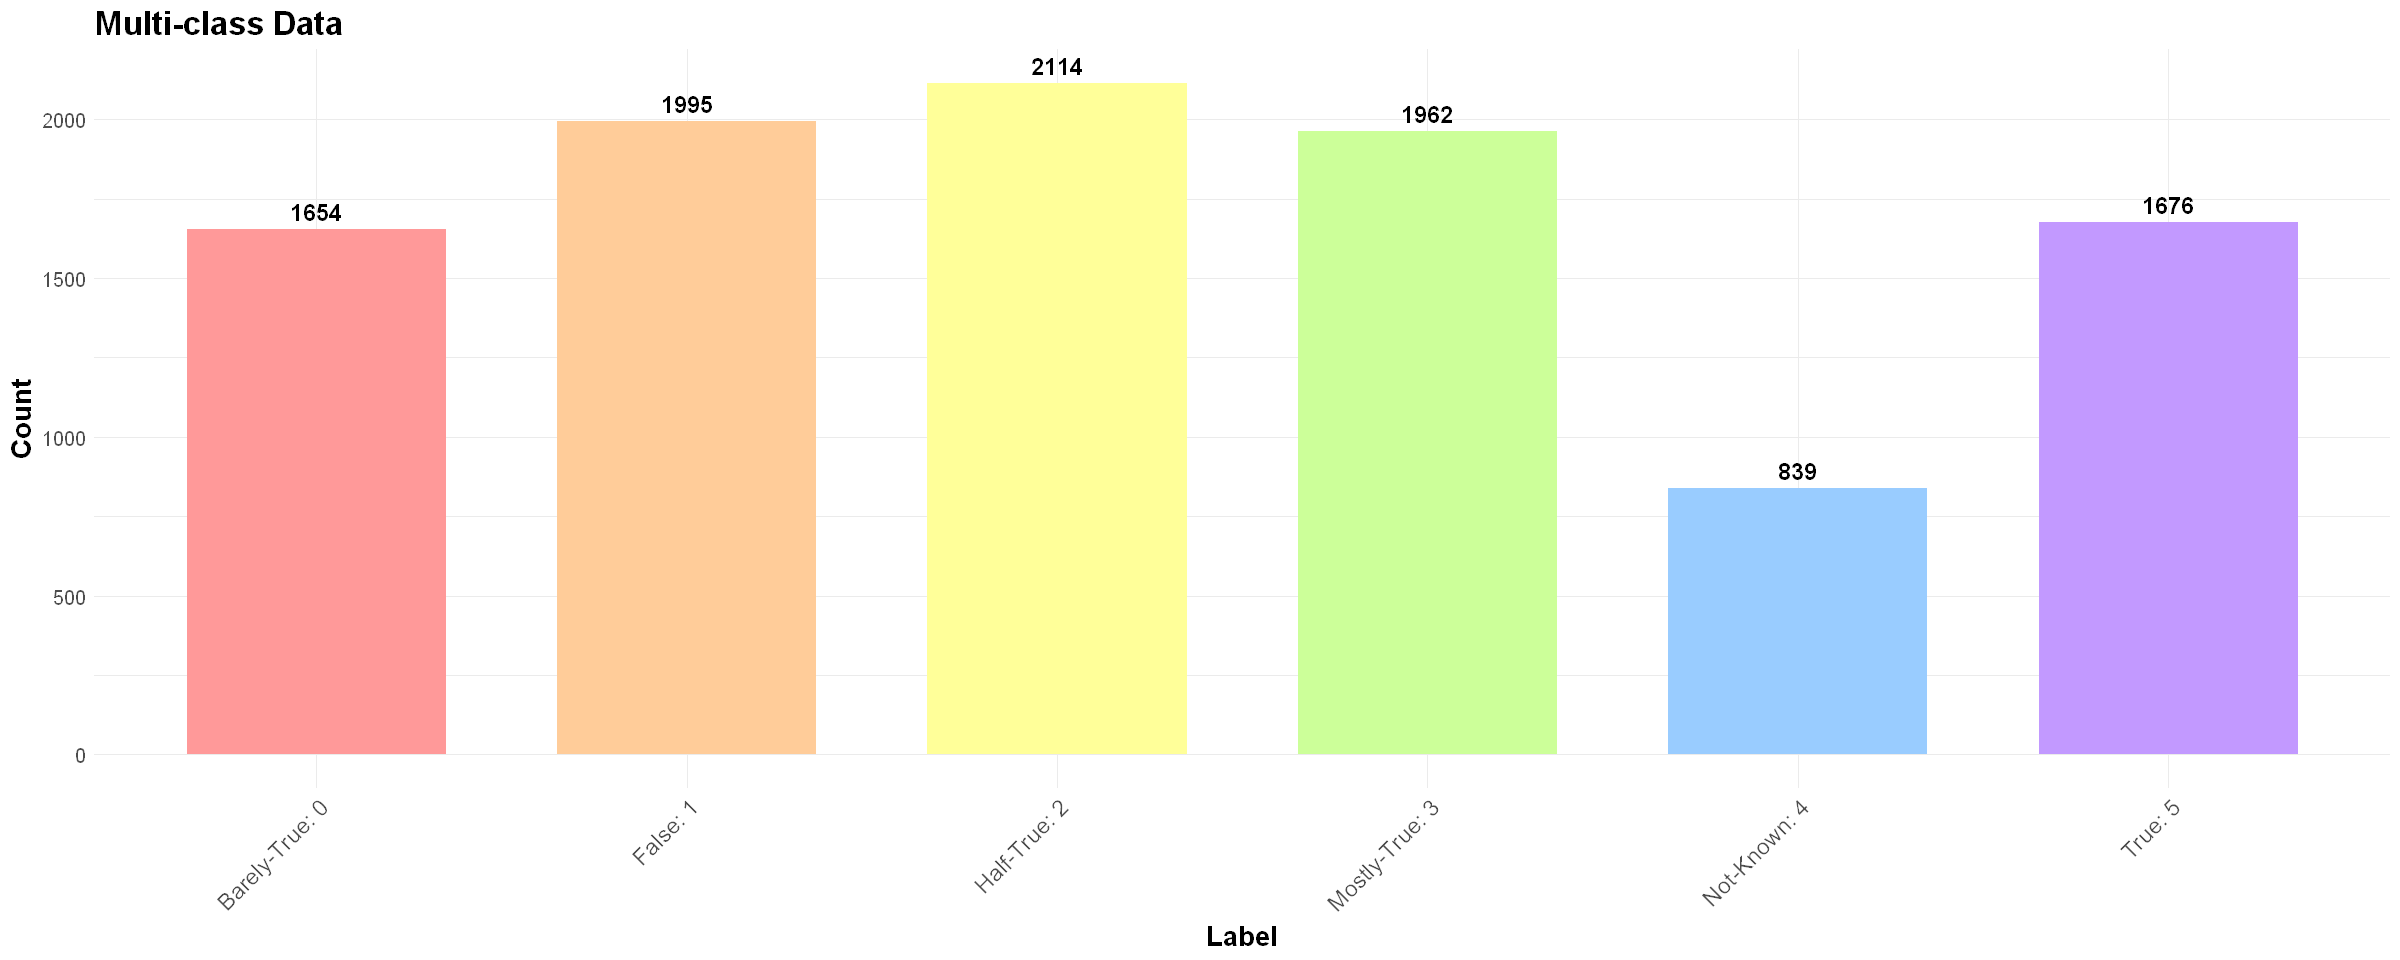

In [9]:
# Convert Labels to factor with descriptive names
trainData1$Label <- factor(trainData1$Labels,
                      levels = 0:5,
                      labels = c("Barely-True: 0", "False: 1", "Half-True: 2",
                                 "Mostly-True: 3", "Not-Known: 4", "True: 5"))

# Define a distinct color palette for better visual differentiation
colors <- c("#FF9999", "#FFCC99", "#FFFF99", "#CCFF99", "#99CCFF", "#C299FF")

# Calculate frequency of each label
label_counts <- as.data.frame(table(trainData1$Label))
colnames(label_counts) <- c("Label", "Count")

# Set base font size
fontsize <- 20

# Plot class distribution with color and frequency labels
p1 <- ggplot(trainData1, aes(x = Label, fill = Label)) +
  geom_bar(width = 0.7, show.legend = FALSE) +
  geom_text(data = label_counts, aes(x = Label, y = Count, label = Count),
            vjust = -0.5, size = 5, fontface = "bold") +
  scale_fill_manual(values = colors) +
  theme_minimal() +
  labs(title = "Multi-class Data",
       x = "Label",
       y = "Count") +
  theme(
    axis.text.x = element_text(size = 14, angle = 45, hjust = 1),
    axis.text.y = element_text(size = 12),
    plot.title = element_text(size = 20, face = "bold"),
    axis.title.x = element_text(size = 16, face = "bold"),
    axis.title.y = element_text(size = 16, face = "bold")
  )

# Display the plot
print(p1)

# Save the plot as a high-resolution PNG
ggsave("label_distribution_multiclass_frequencies.png", plot = p1, width = 8, height = 6, dpi = 300)

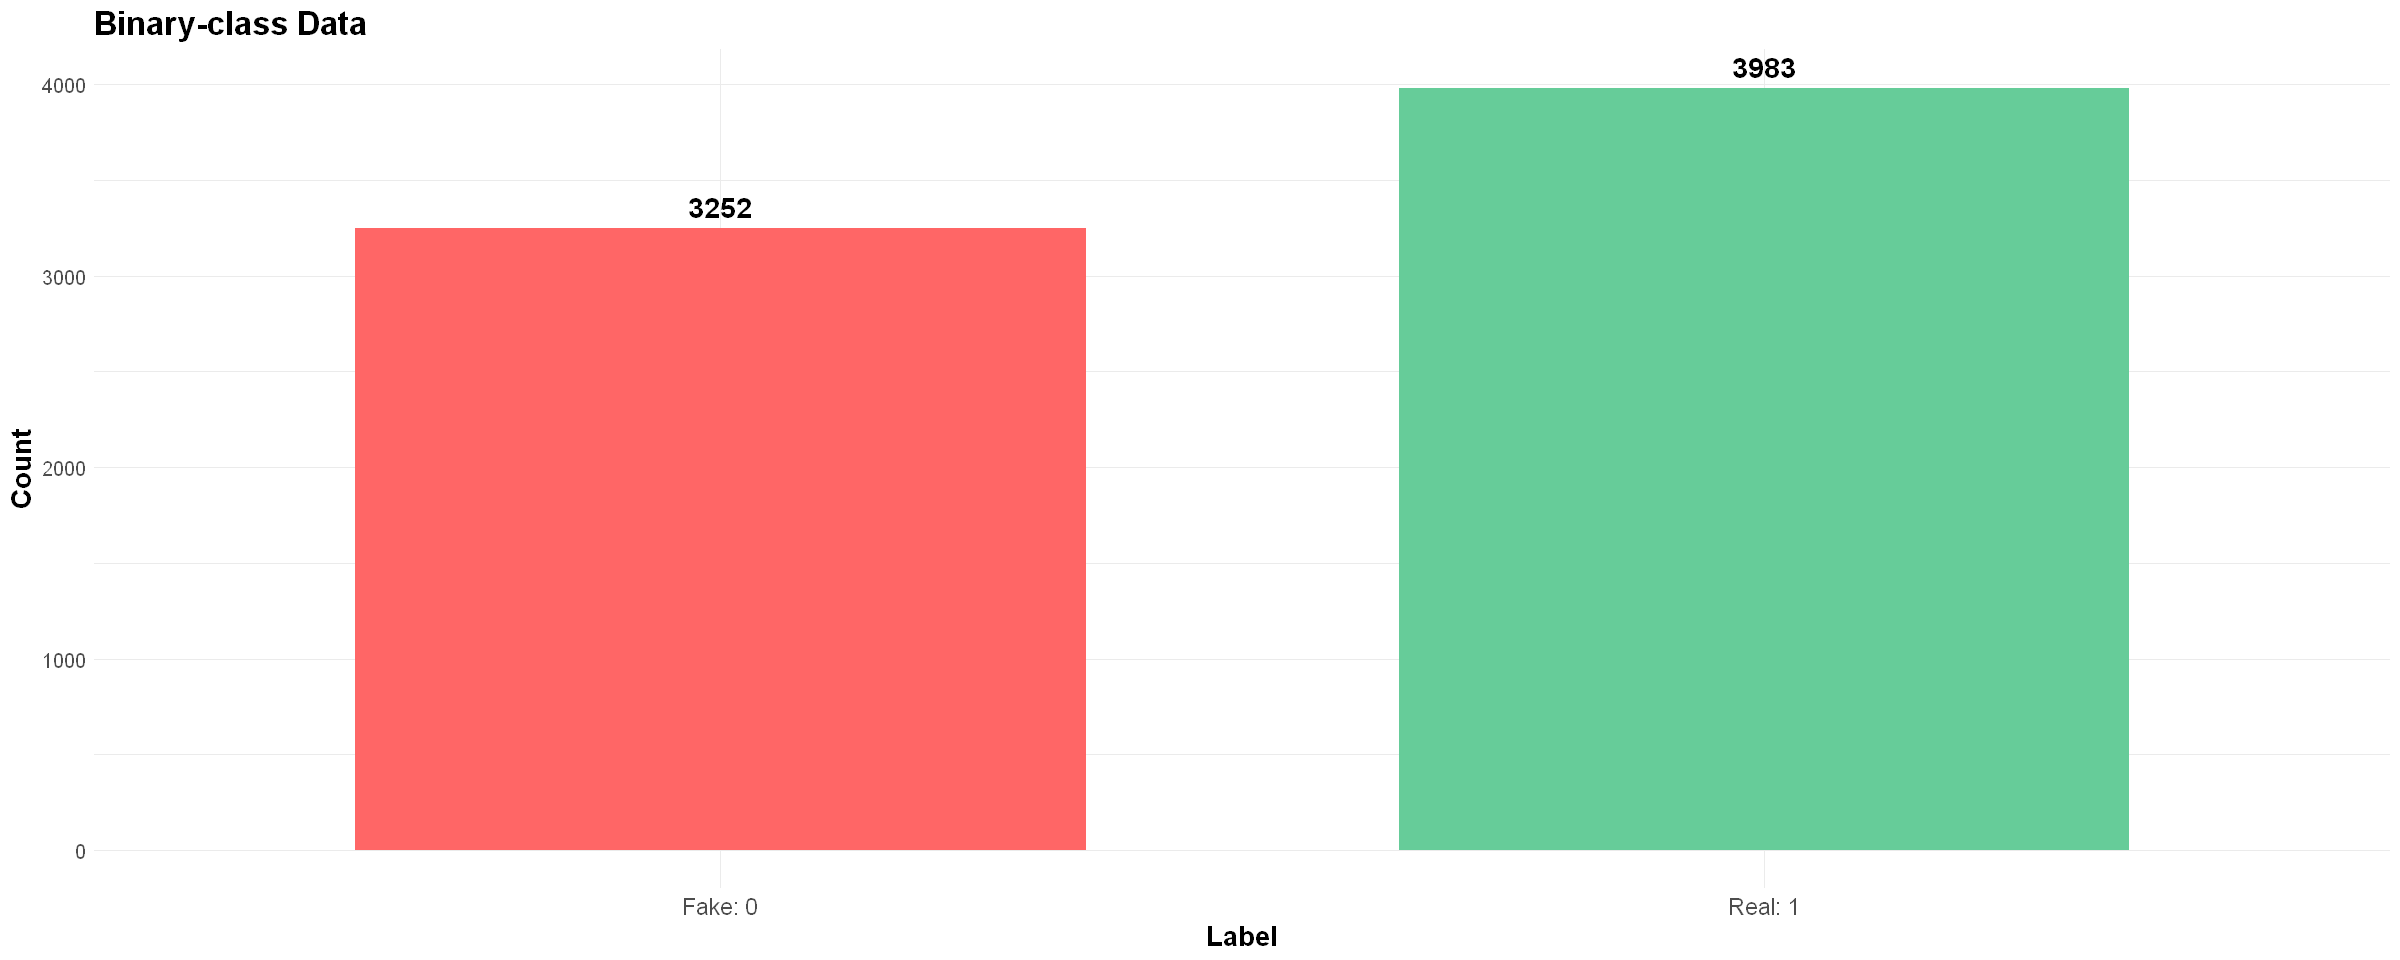

In [10]:
# Convert numeric Labels to categorical with descriptive names
trainData2$Label <- factor(trainData2$Labels,
                           levels = c(0, 1),
                           labels = c("Fake: 0", "Real: 1"))

# Define a color palette for binary labels
colors <- c("#FF6666", "#66CC99")

# Compute label frequencies
label_counts <- as.data.frame(table(trainData2$Label))
colnames(label_counts) <- c("Label", "Count")

# Plot with bar heights and frequency labels
p2 <- ggplot(trainData2, aes(x = Label, fill = Label)) +
  geom_bar(width = 0.7, show.legend = FALSE) +
  geom_text(data = label_counts, aes(x = Label, y = Count, label = Count),
            vjust = -0.5, size = 6, fontface = "bold") +
  scale_fill_manual(values = colors) +
  theme_minimal() +
  labs(title = "Binary-class Data",
       x = "Label",
       y = "Count") +
  theme(
    axis.text.x = element_text(size = 14, angle = 0, hjust = 0.5),
    axis.text.y = element_text(size = 12),
    plot.title = element_text(size = 20, face = "bold"),
    axis.title.x = element_text(size = 16, face = "bold"),
    axis.title.y = element_text(size = 16, face = "bold")
  )

# Display the plot
print(p2)

# Save the plot as PNG
ggsave("label_distribution_binary.png", plot = p2, width = 8, height = 6, dpi = 300)

### Text Length Analysis

We can analyze the length of text in both datasets to understand text complexity.

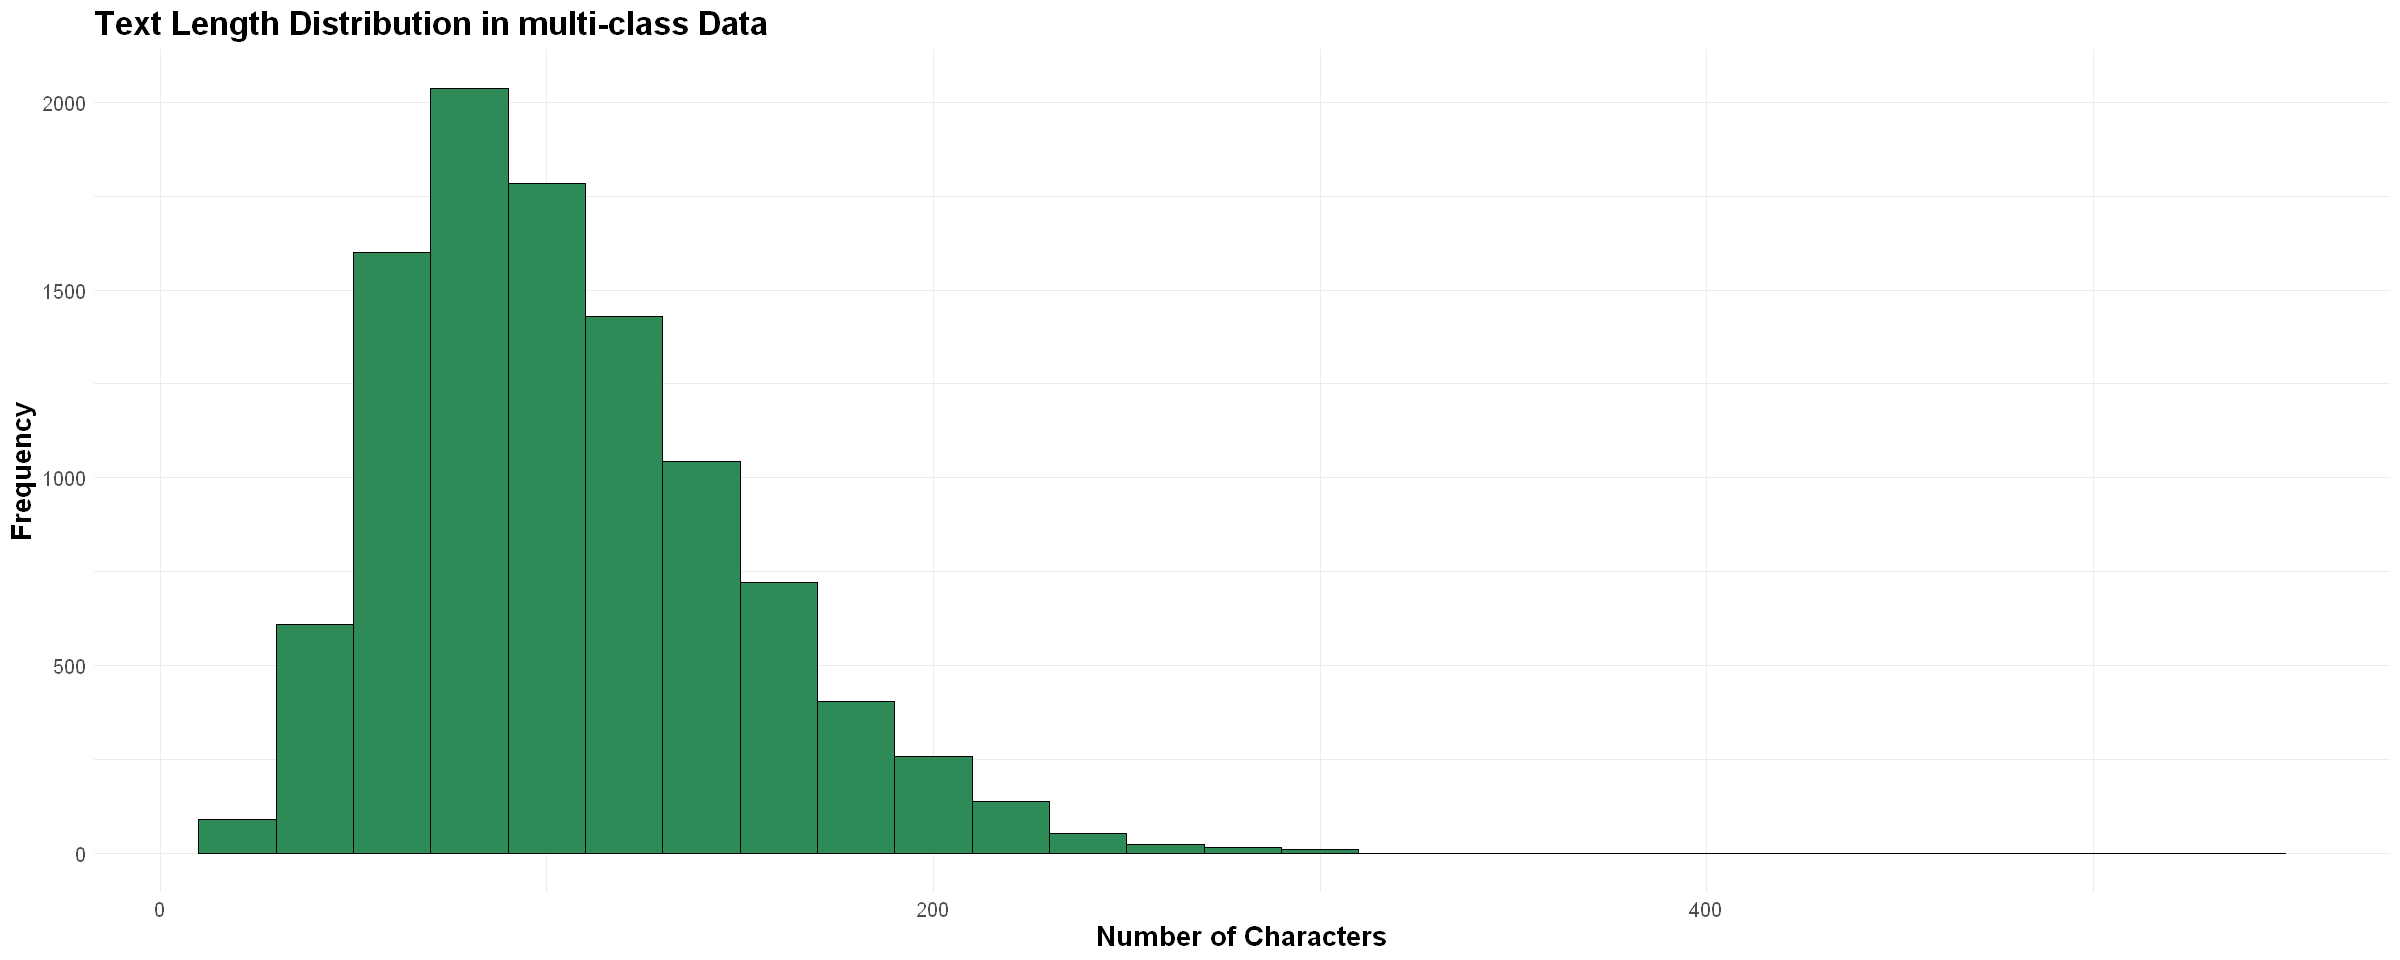

In [11]:
trainData1$Text_Length <- nchar(trainData1$Text)

p3 <- ggplot(filter(trainData1, Text_Length <= 1000), aes(x = Text_Length)) +
  geom_histogram(fill = "seagreen", binwidth = 20, color = "black") +
  theme_minimal() +
  labs(
    title = "Text Length Distribution in multi-class Data",
    x = "Number of Characters",
    y = "Frequency"
  ) +
  theme(
    plot.title = element_text(size = 20, face = "bold"),
    axis.title.x = element_text(size = 16, face = "bold"),
    axis.title.y = element_text(size = 16, face = "bold"),
    axis.text = element_text(size = 12)
  )

# Display the plot
print(p3)

# Save the plot as PNG
ggsave("Text_Length_Distribution_multiclass_Data.png", plot = p3, width = 8, height = 6, dpi = 300)

### Correlation Between Text Length and Labels

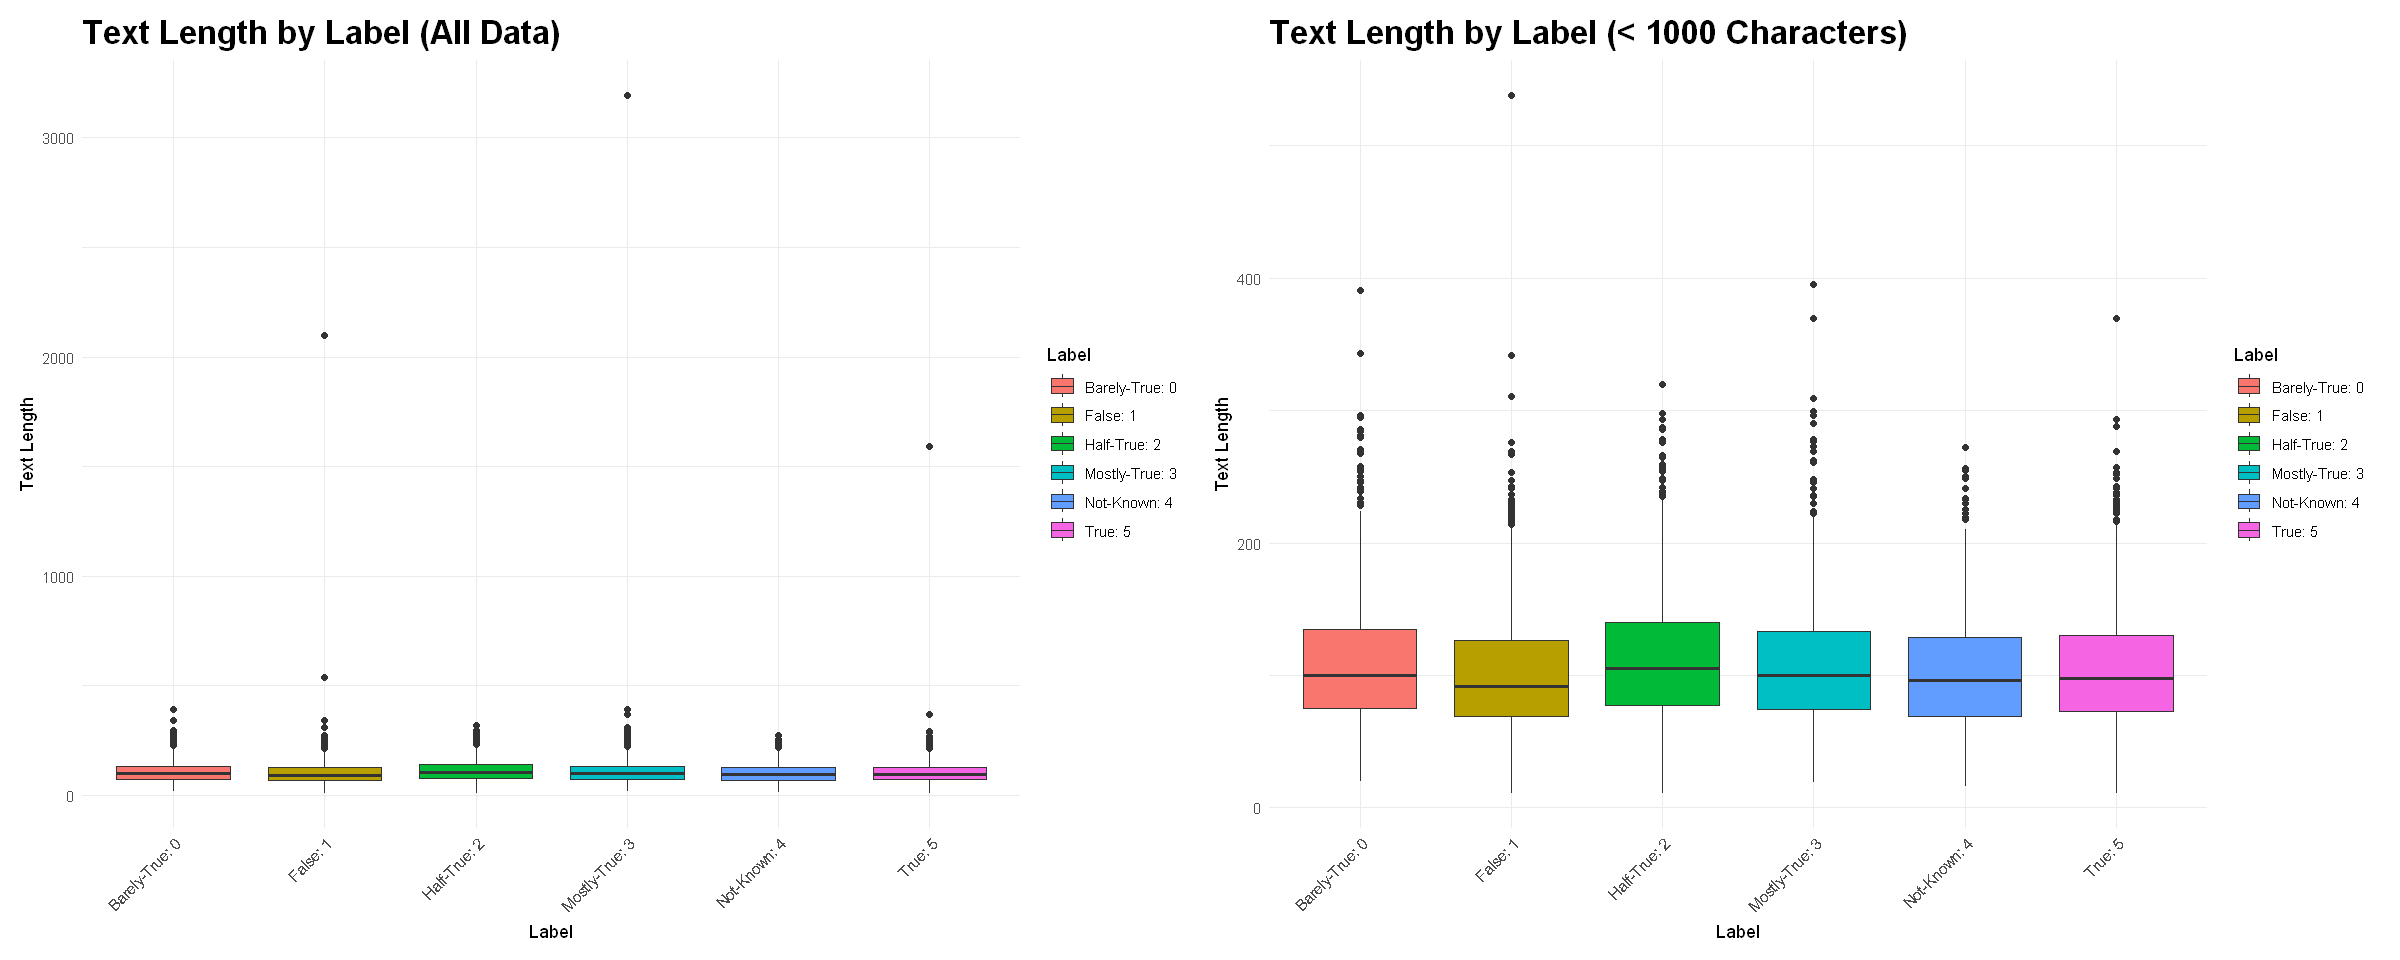

In [12]:
# Boxplot with all samples
p4 <- ggplot(trainData1, aes(x = Label, y = Text_Length, fill = Label)) +
  geom_boxplot() +
  theme_minimal() +
  labs(title = "Text Length by Label (All Data)",
       x = "Label",
       y = "Text Length") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1), 
       plot.title = element_text(size = 20, face = "bold"))

# Boxplot with only Text_Length < 1000
p5 <- ggplot(filter(trainData1, Text_Length < 1000), aes(x = Label, y = Text_Length, fill = Label)) +
  geom_boxplot() +
  theme_minimal() +
  labs(title = "Text Length by Label (< 1000 Characters)",
       x = "Label",
       y = "Text Length") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1), 
       plot.title = element_text(size = 20, face = "bold"))

# Combine plots
combined_plot_1 <- p4 + p5 + plot_layout(ncol = 2)

# Display the plot
print(combined_plot_1)

# Save the combined plot to a file
ggsave("Text_Length_by_Label.png", plot = combined_plot_1, width = 12, height = 6, dpi = 300)

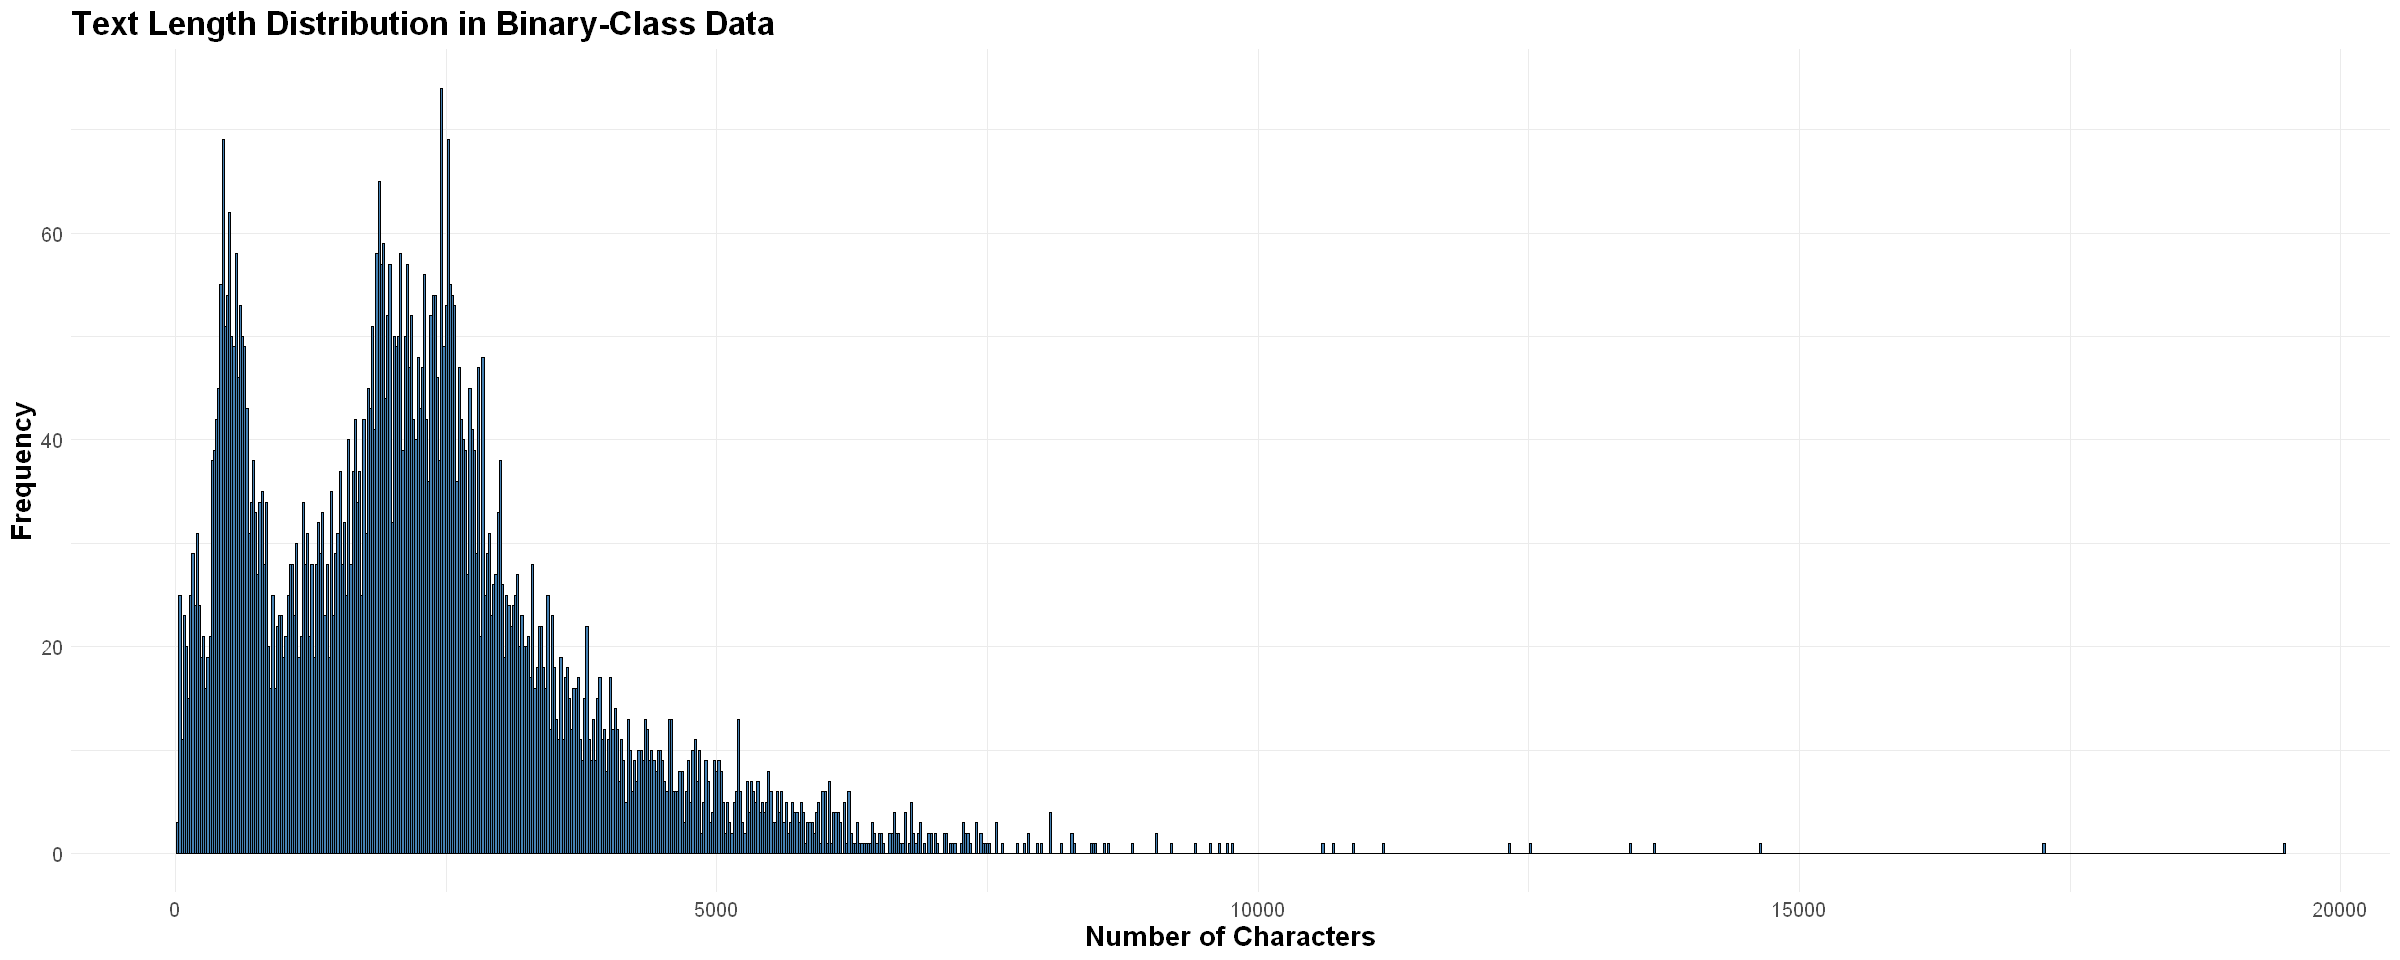

In [13]:
# Calculate text lengths
trainData2$Text_Length <- nchar(trainData2$Text)

# Histogram for all Text_Length values (no filter)
p6 <- ggplot(trainData2, aes(x = Text_Length)) +
  geom_histogram(fill = "steelblue", binwidth = 20, color = "black") +
  theme_minimal() +
  labs(
    title = "Text Length Distribution in Binary-Class Data",
    x = "Number of Characters",
    y = "Frequency"
  ) +
  theme(
    plot.title = element_text(size = 20, face = "bold"),
    axis.title.x = element_text(size = 16, face = "bold"),
    axis.title.y = element_text(size = 16, face = "bold"),
    axis.text = element_text(size = 12)
  )

# Display and save the histogram
print(p6)
ggsave("Text_Length_Distribution_Binary_Data_All_Range.png", plot = p6, width = 8, height = 6, dpi = 300)

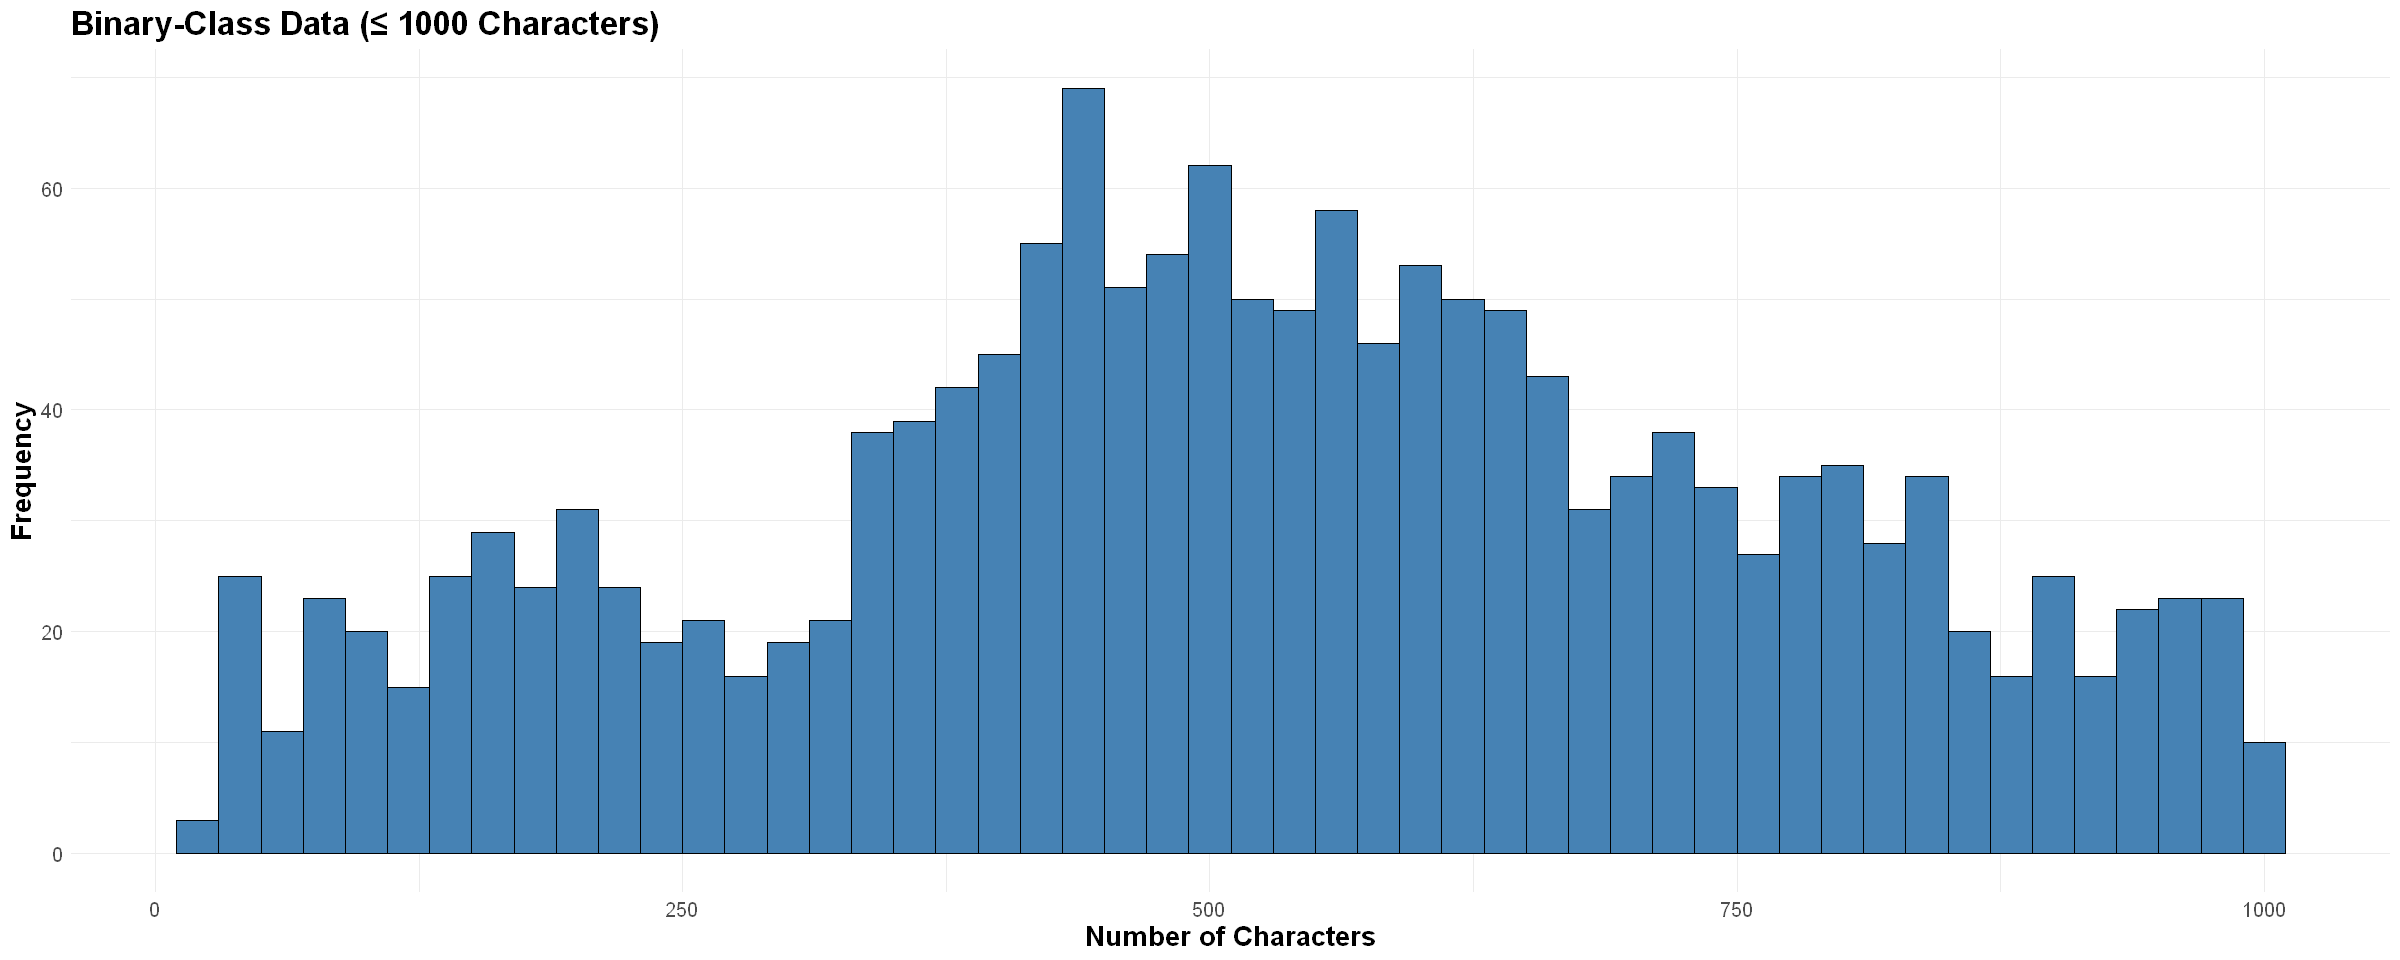

In [14]:
# Calculate text lengths
trainData2$Text_Length <- nchar(trainData2$Text)

# Histogram for Text_Length ≤ 1000
p7 <- ggplot(filter(trainData2, Text_Length <= 1000), aes(x = Text_Length)) +
  geom_histogram(fill = "steelblue", binwidth = 20, color = "black") +
  theme_minimal() +
  labs(
    title = "Binary-Class Data (≤ 1000 Characters)",
    x = "Number of Characters",
    y = "Frequency"
  ) +
  theme(
    plot.title = element_text(size = 20, face = "bold"),
    axis.title.x = element_text(size = 16, face = "bold"),
    axis.title.y = element_text(size = 16, face = "bold"),
    axis.text = element_text(size = 12)
  )

# Display and save the histogram
print(p7)
ggsave("Text_Length_Distribution_Binary_Data.png", plot = p7, width = 8, height = 6, dpi = 300)

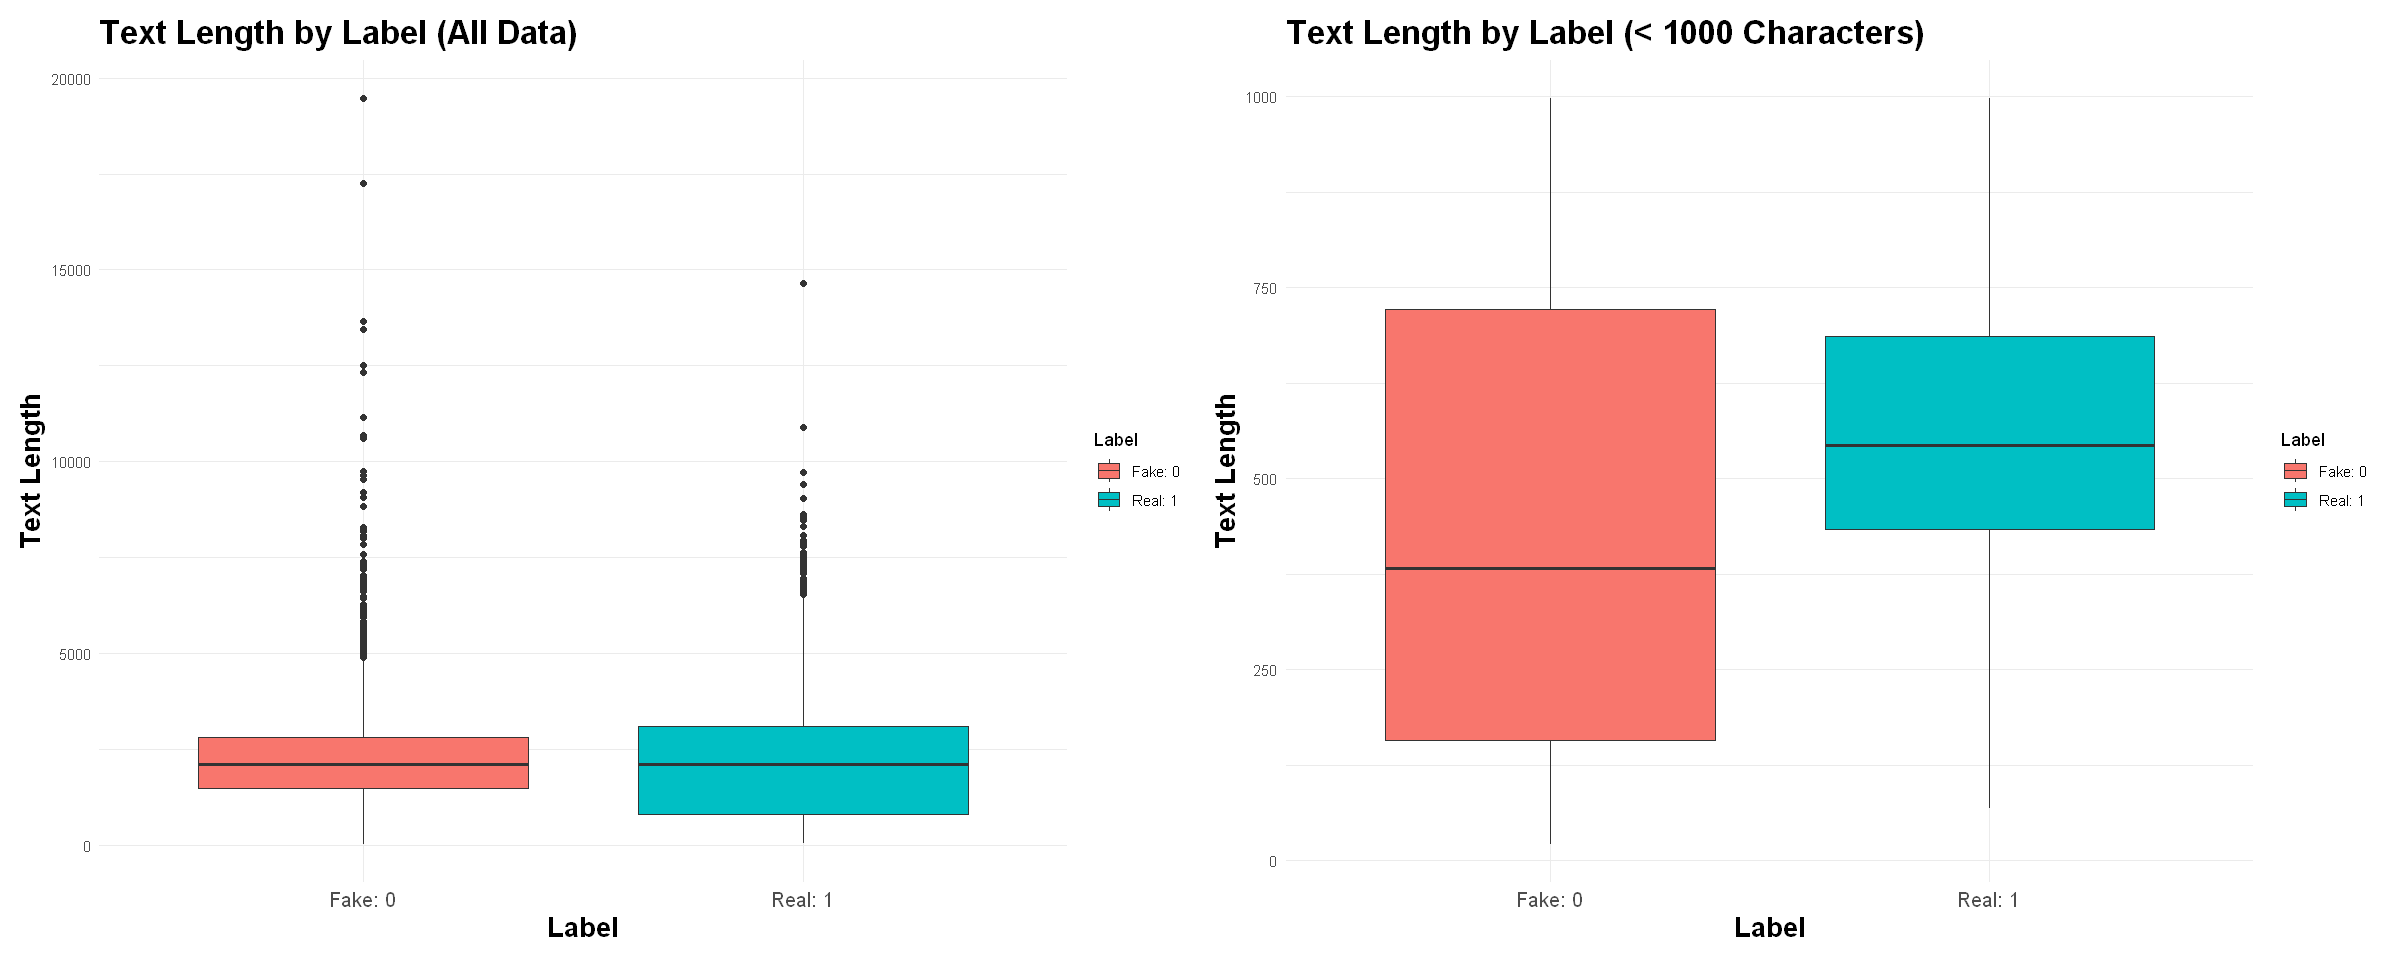

In [15]:
# Boxplot for all text lengths
p8 <- ggplot(trainData2, aes(x = Label, y = Text_Length, fill = Label)) +
  geom_boxplot() +
  theme_minimal() +
  labs(title = "Text Length by Label (All Data)",
       x = "Label",
       y = "Text Length") +
  theme(
    axis.text.x = element_text(angle = 0, size = 12),
    axis.title = element_text(size = 16, face = "bold"),
    plot.title = element_text(size = 20, face = "bold")
  )

# Boxplot for Text_Length < 1000
p9 <- ggplot(filter(trainData2, Text_Length < 1000), aes(x = Label, y = Text_Length, fill = Label)) +
  geom_boxplot() +
  theme_minimal() +
  labs(title = "Text Length by Label (< 1000 Characters)",
       x = "Label",
       y = "Text Length") +
  theme(
    axis.text.x = element_text(angle = 0, size = 12),
    axis.title = element_text(size = 16, face = "bold"),
    plot.title = element_text(size = 20, face = "bold")
  )

# Combine both boxplots side by side
combined_plot_2 <- p8 + p9 + plot_layout(ncol = 2)

# Display and save the combined plot
print(combined_plot_2)
ggsave("Text_Length_by_Label_Binary.png", plot = combined_plot_2, width = 12, height = 6, dpi = 300)

### Visualize News Categories (Text_Tag) Distribution

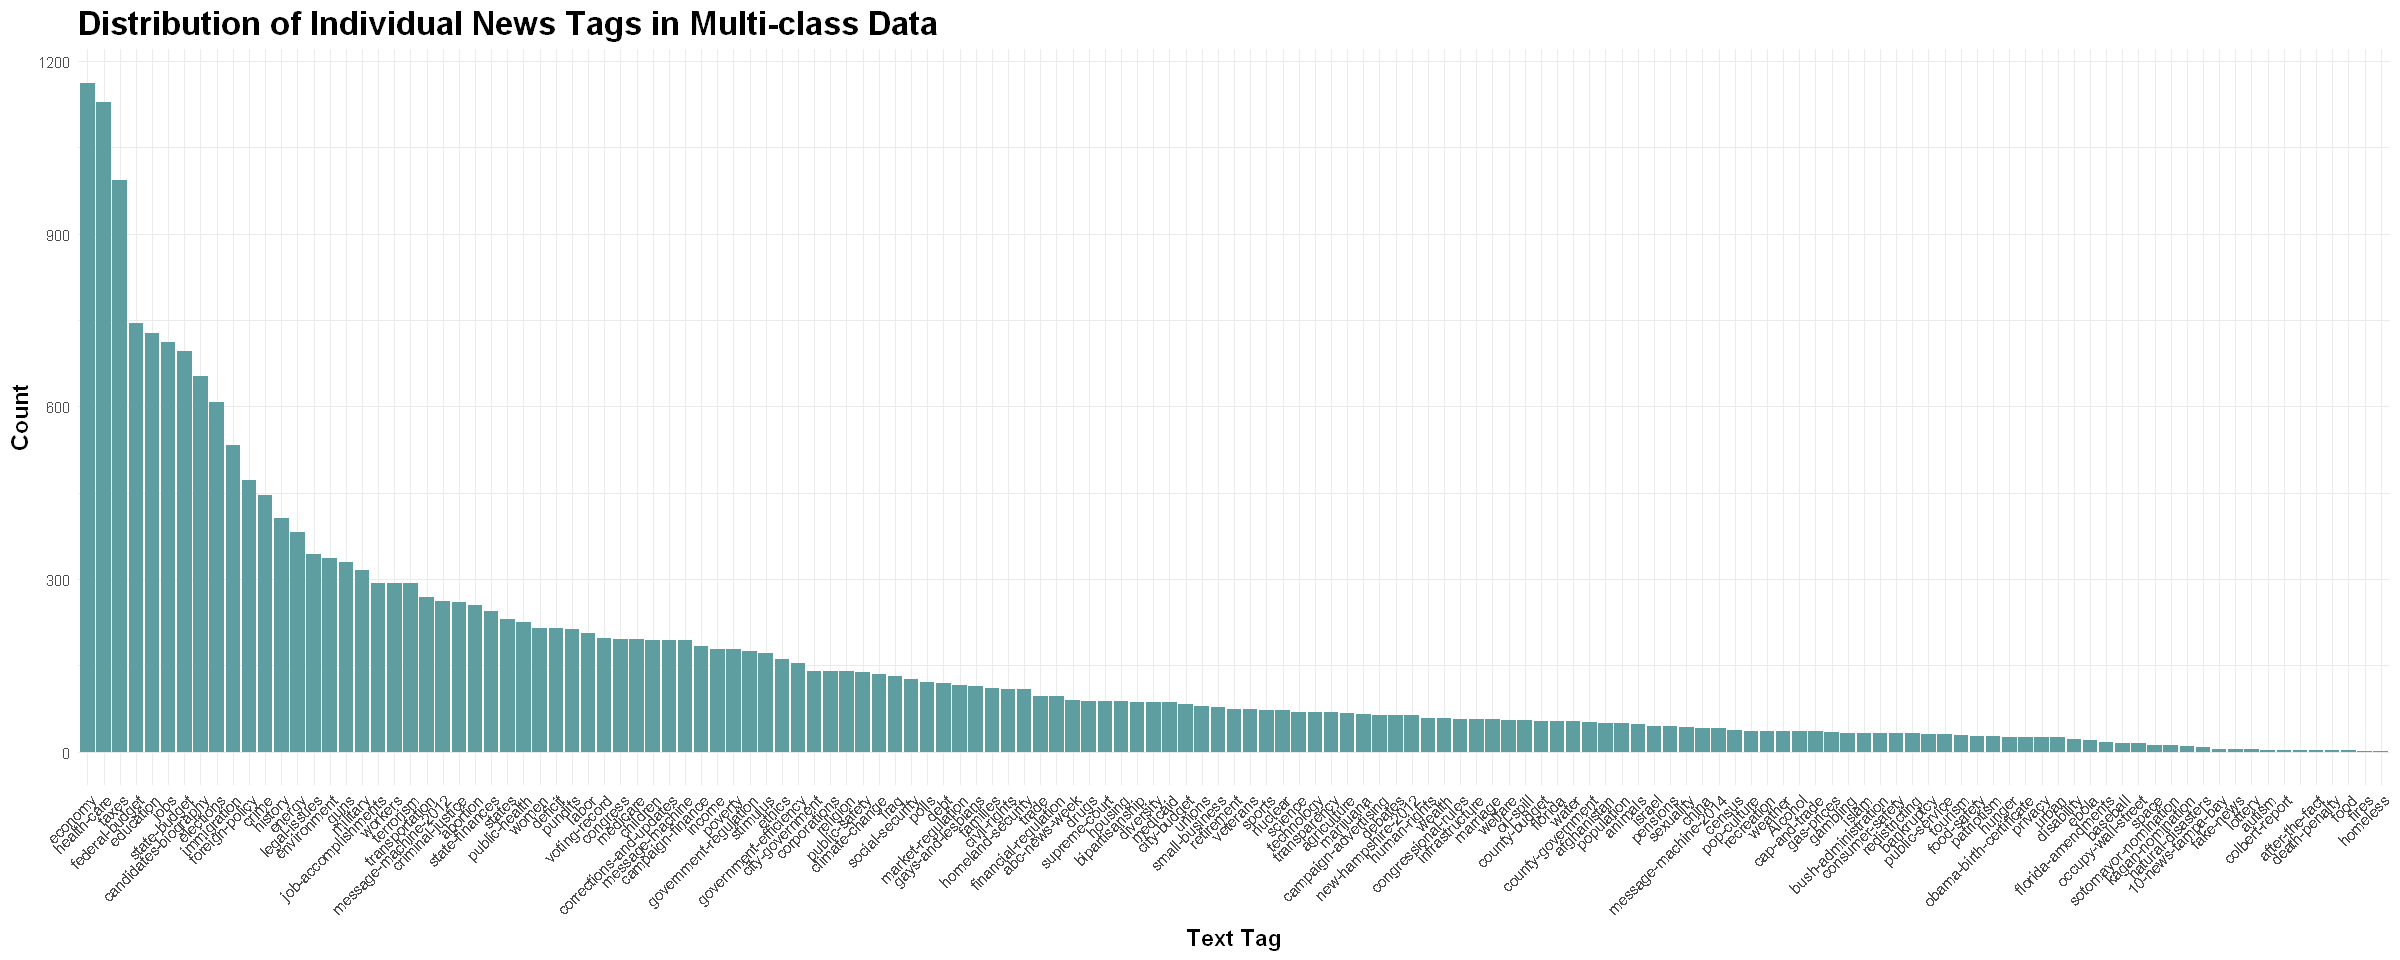

In [16]:
# Split the tags into individual rows
trainData1_tags <- trainData1 %>%
  separate_rows(Text_Tag, sep = ",") %>%
  mutate(Text_Tag = str_trim(Text_Tag))  # Remove leading/trailing whitespace

# Create the plot
p_10 <- ggplot(trainData1_tags, aes(x = fct_infreq(Text_Tag))) +
  geom_bar(fill = "cadetblue") +
  theme_minimal() +
  labs(title = "Distribution of Individual News Tags in Multi-class Data",
       x = "Text Tag",
       y = "Count") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title = element_text(size = 20, face = "bold"),
    axis.title.x = element_text(size = 14, face = "bold"),
    axis.title.y = element_text(size = 14, face = "bold")
  )

# Display the plot
print(p_10)

# Save the plot as a PNG file
ggsave("Text_Tag_Distribution.png", plot = p_10, width = 20, height = 8, dpi = 300)

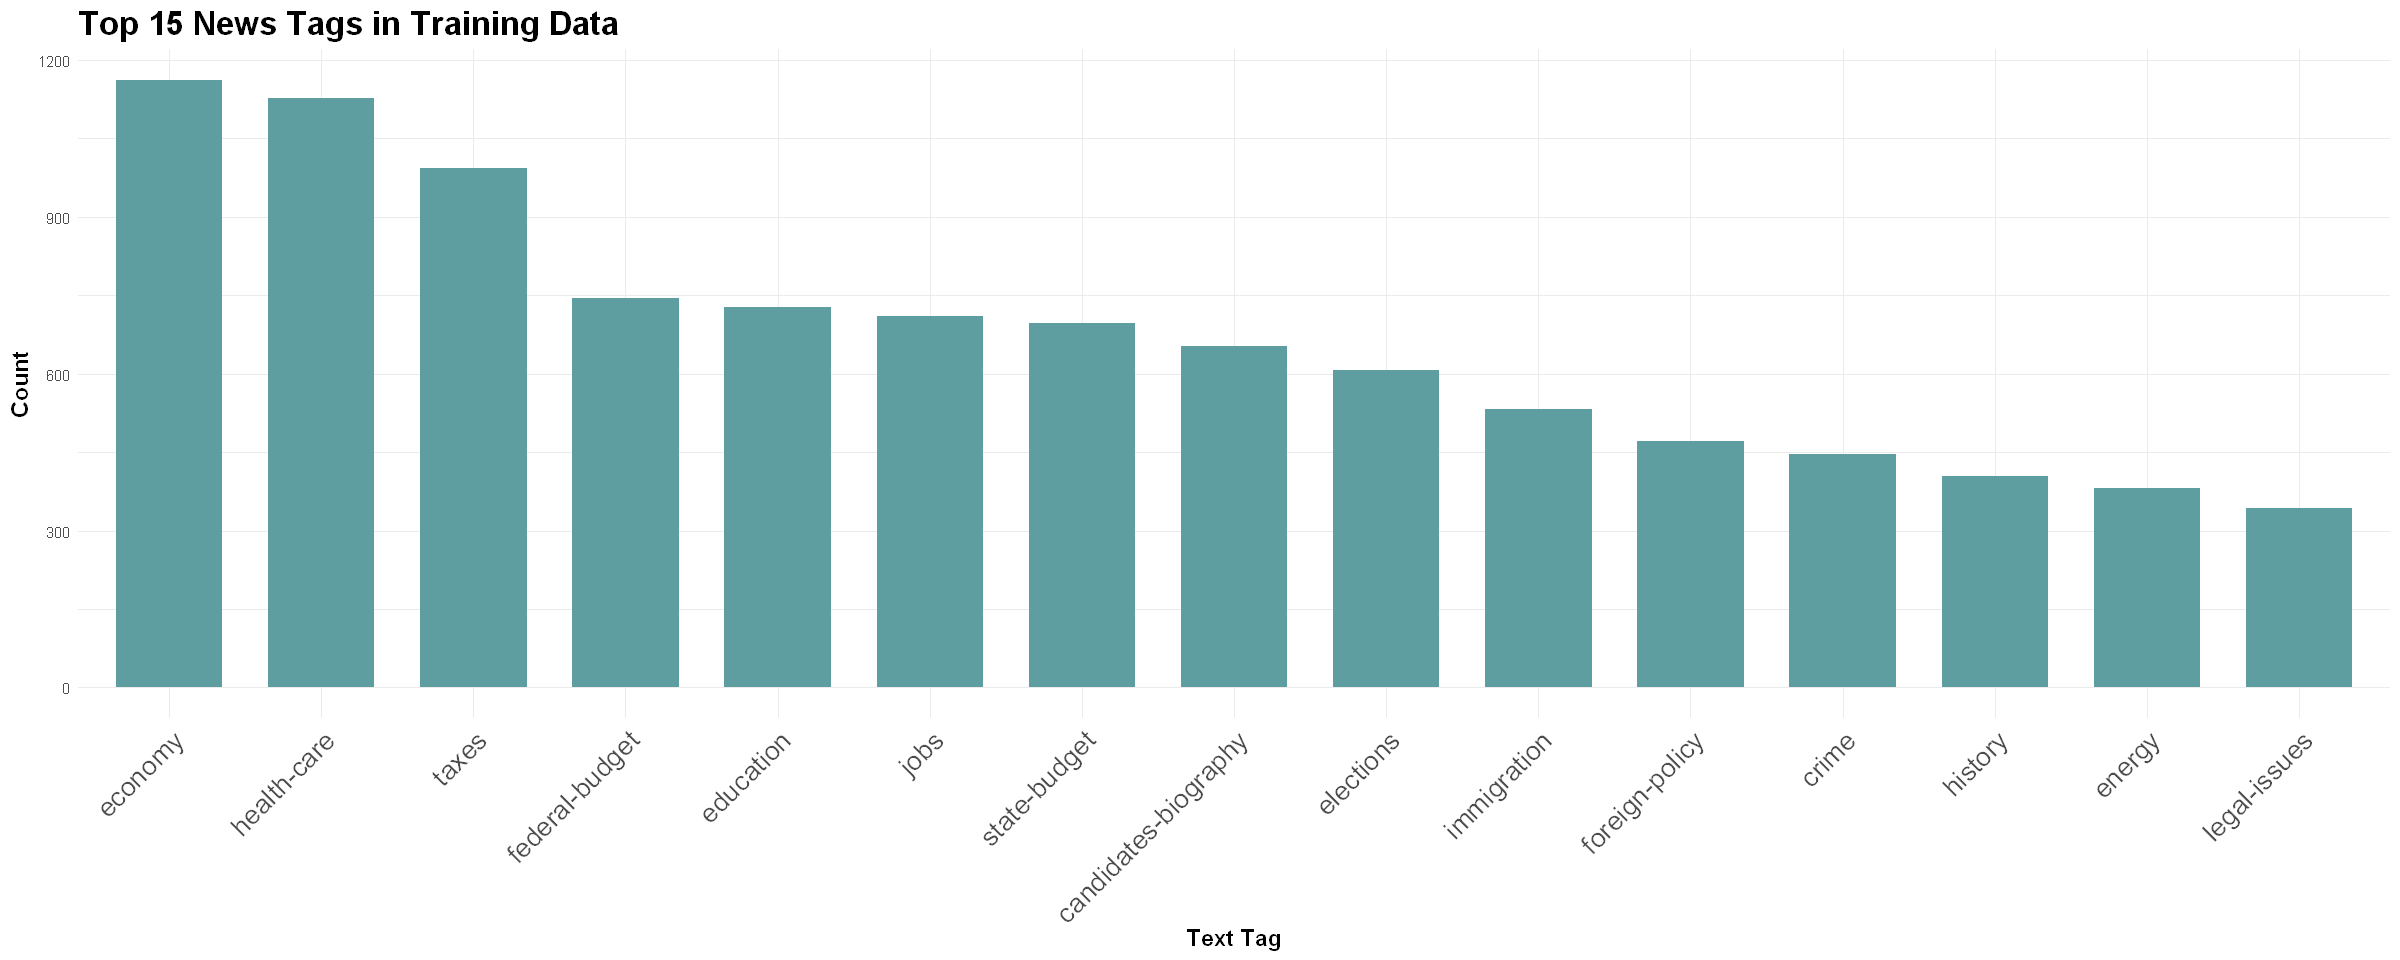

In [17]:
top_tags <- trainData1_tags %>%
  count(Text_Tag, sort = TRUE) %>%
  slice_head(n = 15)

p_11 <- trainData1_tags %>%
  filter(Text_Tag %in% top_tags$Text_Tag) %>%
  ggplot(aes(x = fct_infreq(Text_Tag))) +
  geom_bar(fill = "cadetblue", width=0.7) +
  theme_minimal() +
  labs(title = "Top 15 News Tags in Training Data",
       x = "Text Tag",
       y = "Count") +
  theme(axis.text.x = element_text(size = 16, angle = 45, hjust = 1),
        plot.title = element_text(size = 20, face = "bold"),
        axis.title.x = element_text(size = 14, face = "bold"),
        axis.title.y = element_text(size = 14, face = "bold"))

# Display the plot
print(p_11)

# Save the plot as a PNG file
ggsave("Text_Tag_Distribution_Top15.png", plot = p_11, width = 20, height = 8, dpi = 300)

### Label Distribution per Category 

This shows how each category (Text_Tag) is distributed across labels.

#### Plot only Top N Categories (e.g., Top 10)

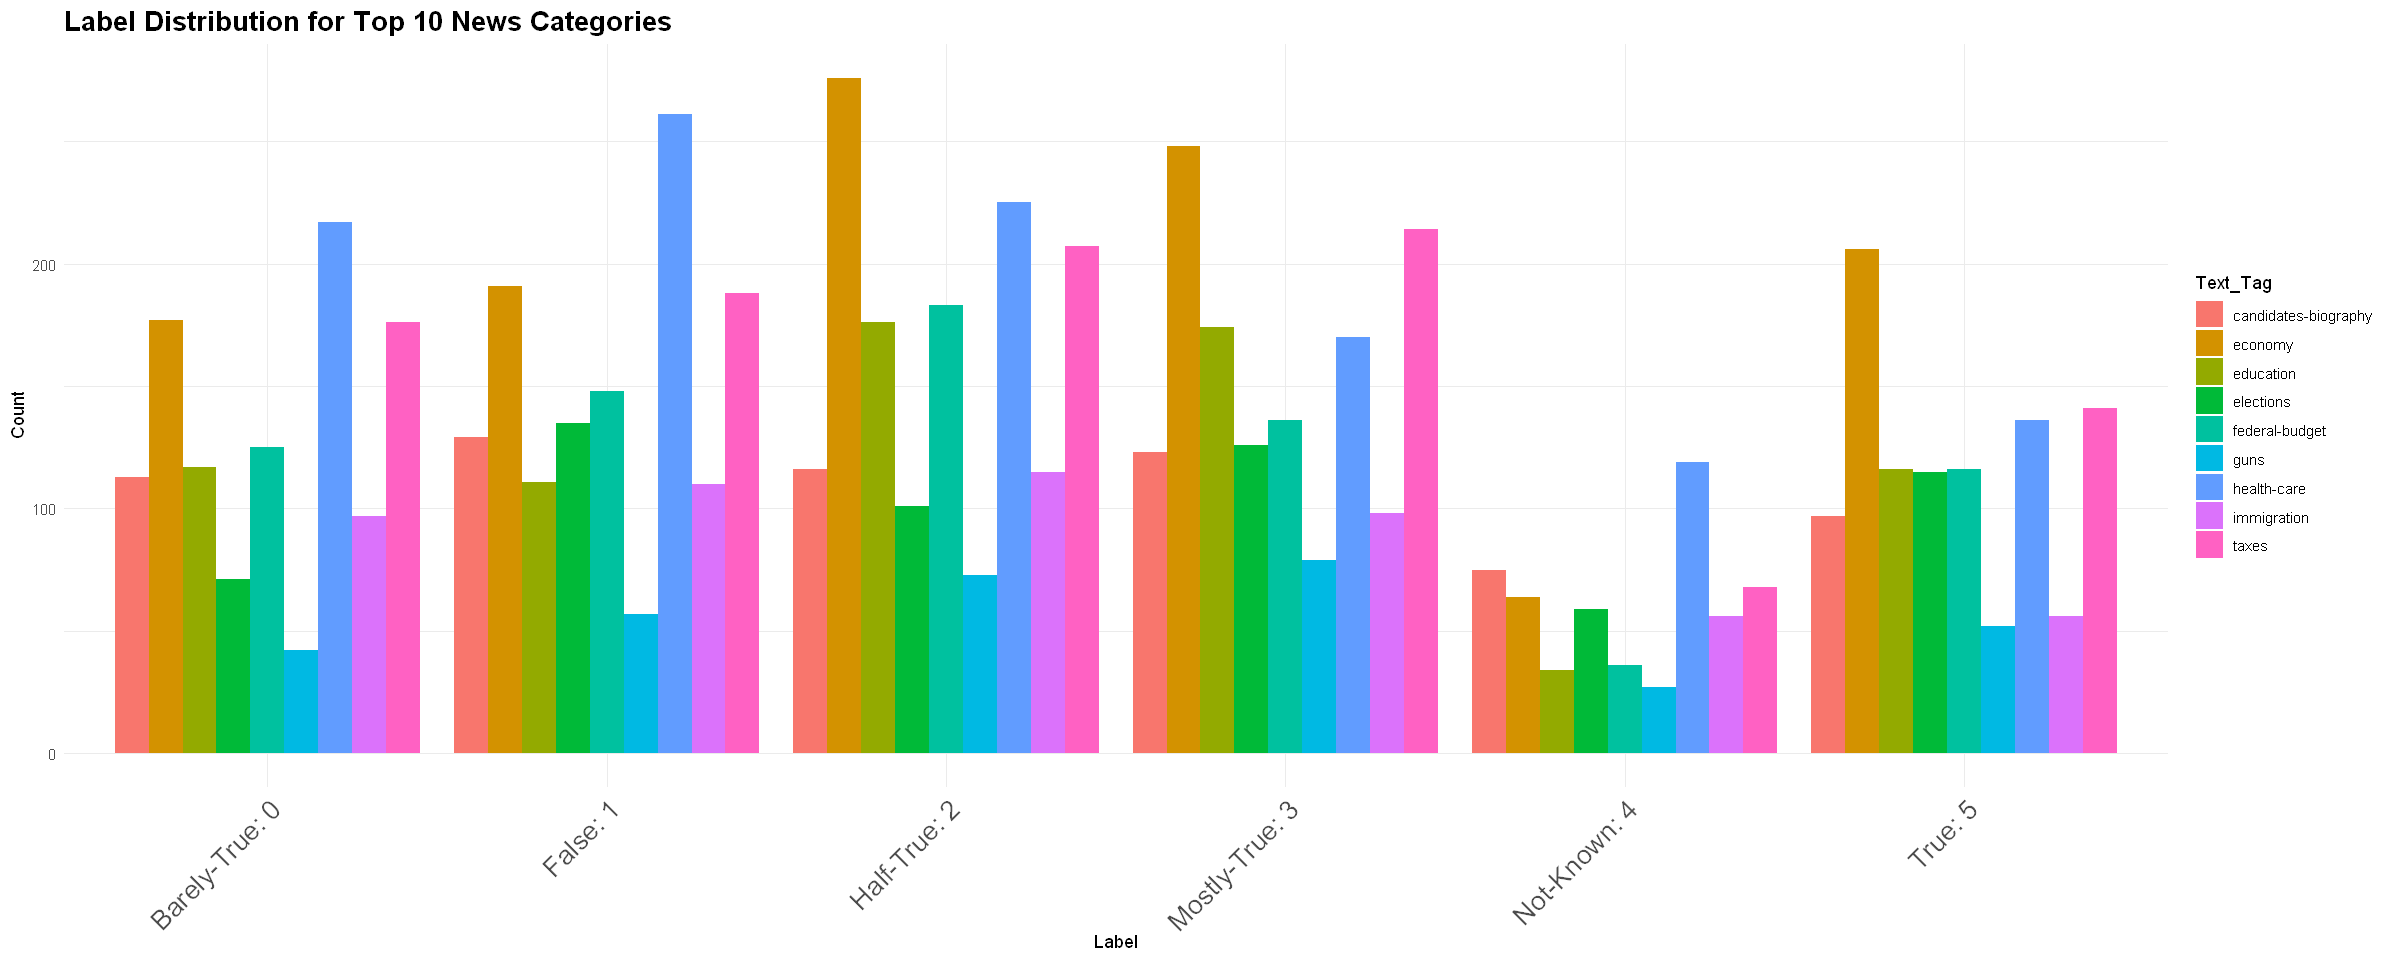

In [18]:
# Step 1: Count top categories
top_tags <- trainData1 %>%
  count(Text_Tag, sort = TRUE) %>%
  slice_head(n = 10) %>%
  pull(Text_Tag)

# Step 2: Filter data for top categories only
filtered_train <- trainData1 %>%
  separate_rows(Text_Tag, sep = ",") %>%
  mutate(Text_Tag = str_trim(Text_Tag)) %>%
  filter(Text_Tag %in% top_tags)

# Step 3: Plot
p_12 <- ggplot(filtered_train, aes(x = Label, fill = Text_Tag)) +
  geom_bar(position = "dodge") +
  theme_minimal() +
  labs(title = "Label Distribution for Top 10 News Categories",
       x = "Label",
       y = "Count") +
  theme(axis.text.x = element_text(size = 16, angle = 45, hjust = 1),
        plot.title = element_text(size = 16, face = "bold"))

# Display the plot
print(p_12)

# Save the plot as a PNG file
ggsave("Text_Tag_Distribution_Top15.png", plot = p_12, width = 20, height = 8, dpi = 300)

#### Faceted Plots per Top Category

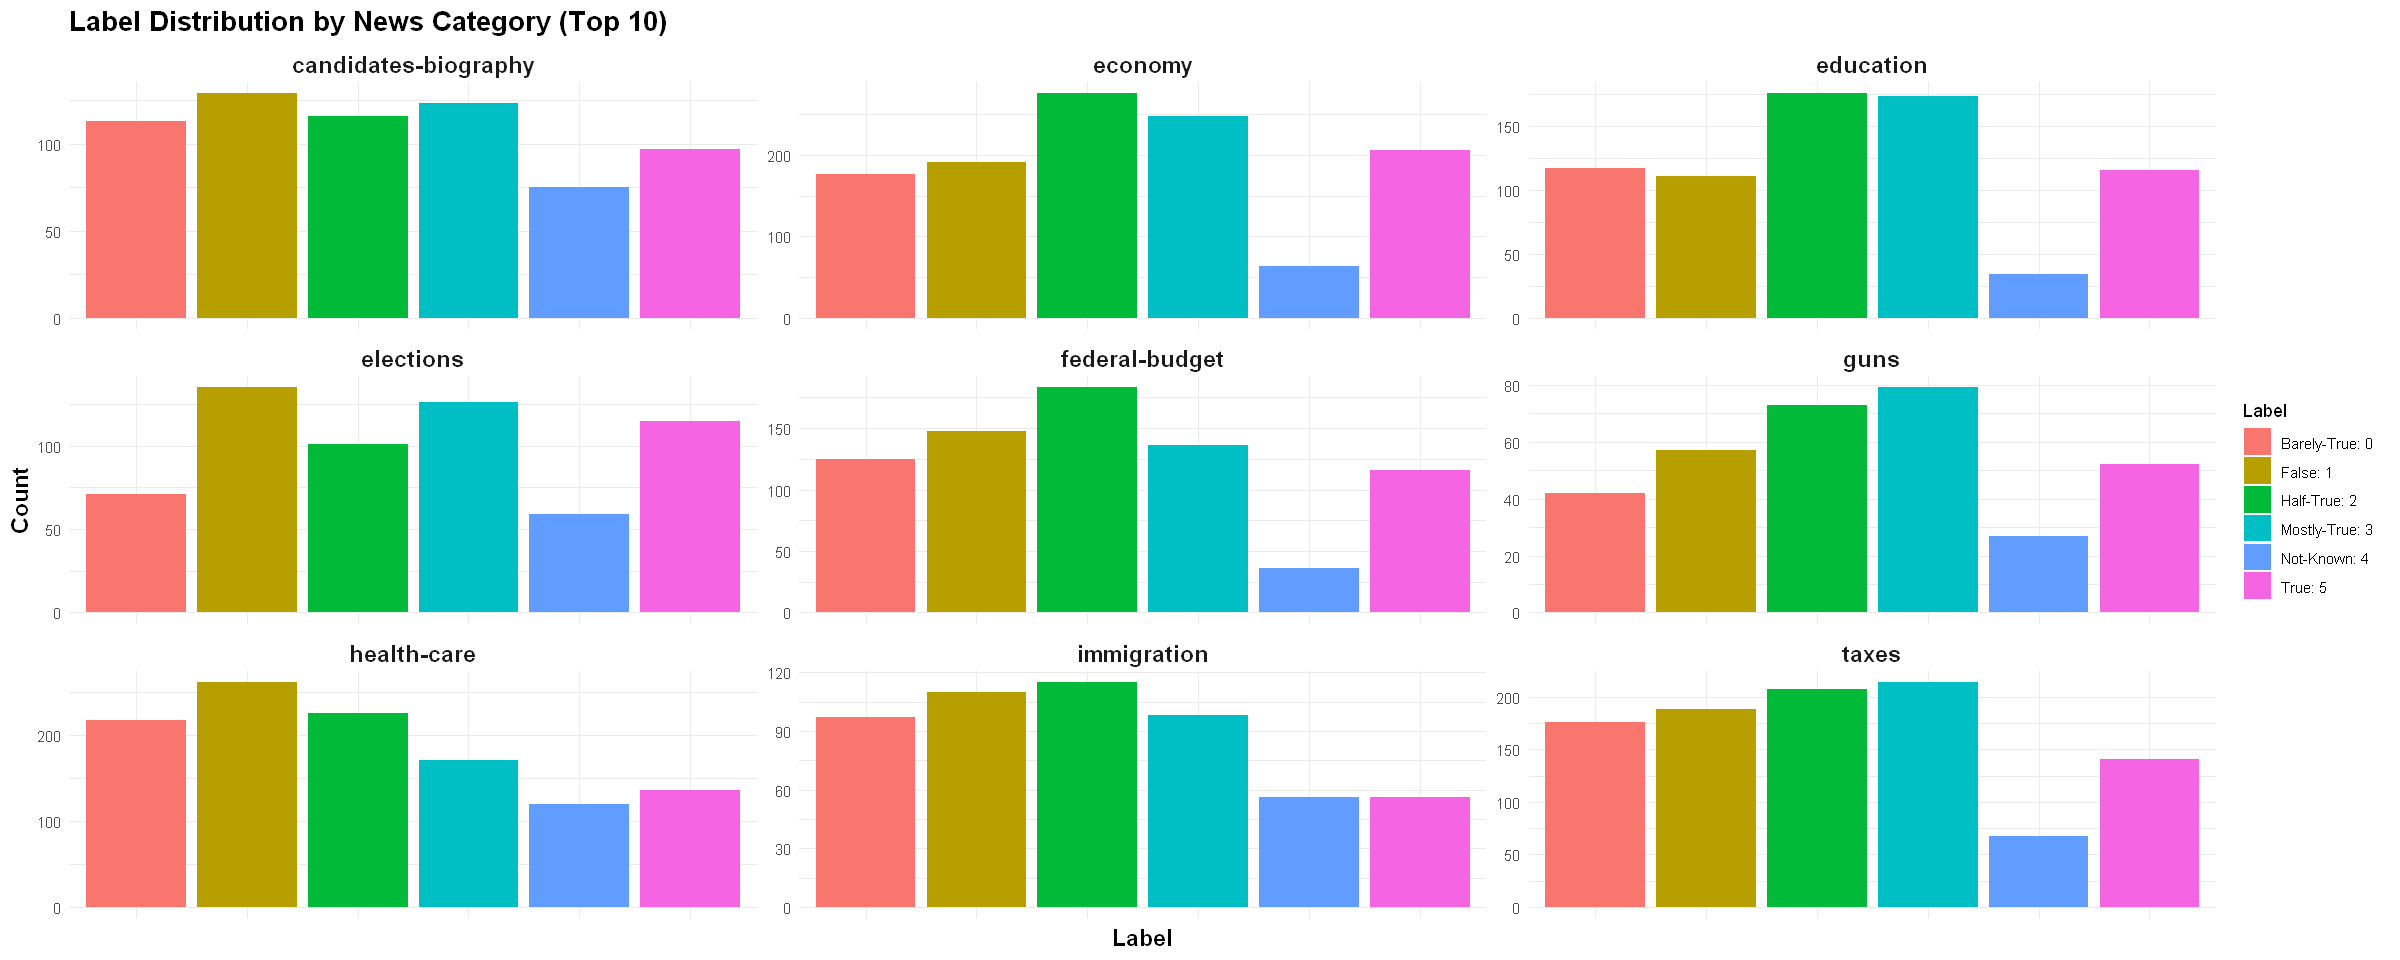

In [19]:
p_13 <- ggplot(filtered_train, aes(x = Label, fill = Label)) +
  geom_bar() +
  facet_wrap(~ Text_Tag, scales = "free_y") +
  theme_minimal() +
  labs(title = "Label Distribution by News Category (Top 10)",
       x = "Label",
       y = "Count") +
  theme(
    axis.text.x = element_blank(),  # Remove x-axis text
    axis.ticks.x = element_blank(), # Optional: remove x-axis ticks
    plot.title = element_text(size = 16, face = "bold"),
    strip.text = element_text(size = 14, face = "bold"), # Make facet titles larger
    axis.title.x = element_text(size = 14, face = "bold"),
    axis.title.y = element_text(size = 14, face = "bold")
  )

# Display the plot
print(p_13)

# Optionally save the plot
ggsave("Label_Distribution_by_Top10_Tags.png", plot = p_13, width = 20, height = 8, dpi = 300)

## Train-validation split

Since the test dataset does not contain labels, we cannot use it to measure the performance of our model after training. Therefore, we need to make a train-validation split of the training data. In order to perform our split we will use the **caret** package, which allows us to ensure stratified sampling.

In [20]:
fakeNewsTrain <- read.csv("./Data/train.csv")

# Set random seed for reproducibility
set.seed(42)

# Draw a random, stratified sample including p percent of the data
idx.train <- createDataPartition(y = fakeNewsTrain$Labels, 
                                 p = 0.8, list = FALSE)

# Training set with p = 0.8
trainData <- fakeNewsTrain[idx.train, ]

# Validation set with p = 0.2
validationData <- fakeNewsTrain[-idx.train, ]

#### Label Distribution Comparison Between Training and Validation Sets

In [21]:
# Prepare combined data frame for visualization
concat_data <- c(trainData$Labels, validationData$Labels)
group <- c(rep("Train", nrow(trainData)), rep("Validation", nrow(validationData)))
df <- data.frame(
  Label = factor(concat_data, levels = 0:5,
                 labels = c("Barely-True: 0", "False: 1", "Half-True: 2", 
                            "Mostly-True: 3", "Not-Known: 4", "True: 5")),
  x = concat_data,
  group = group
)

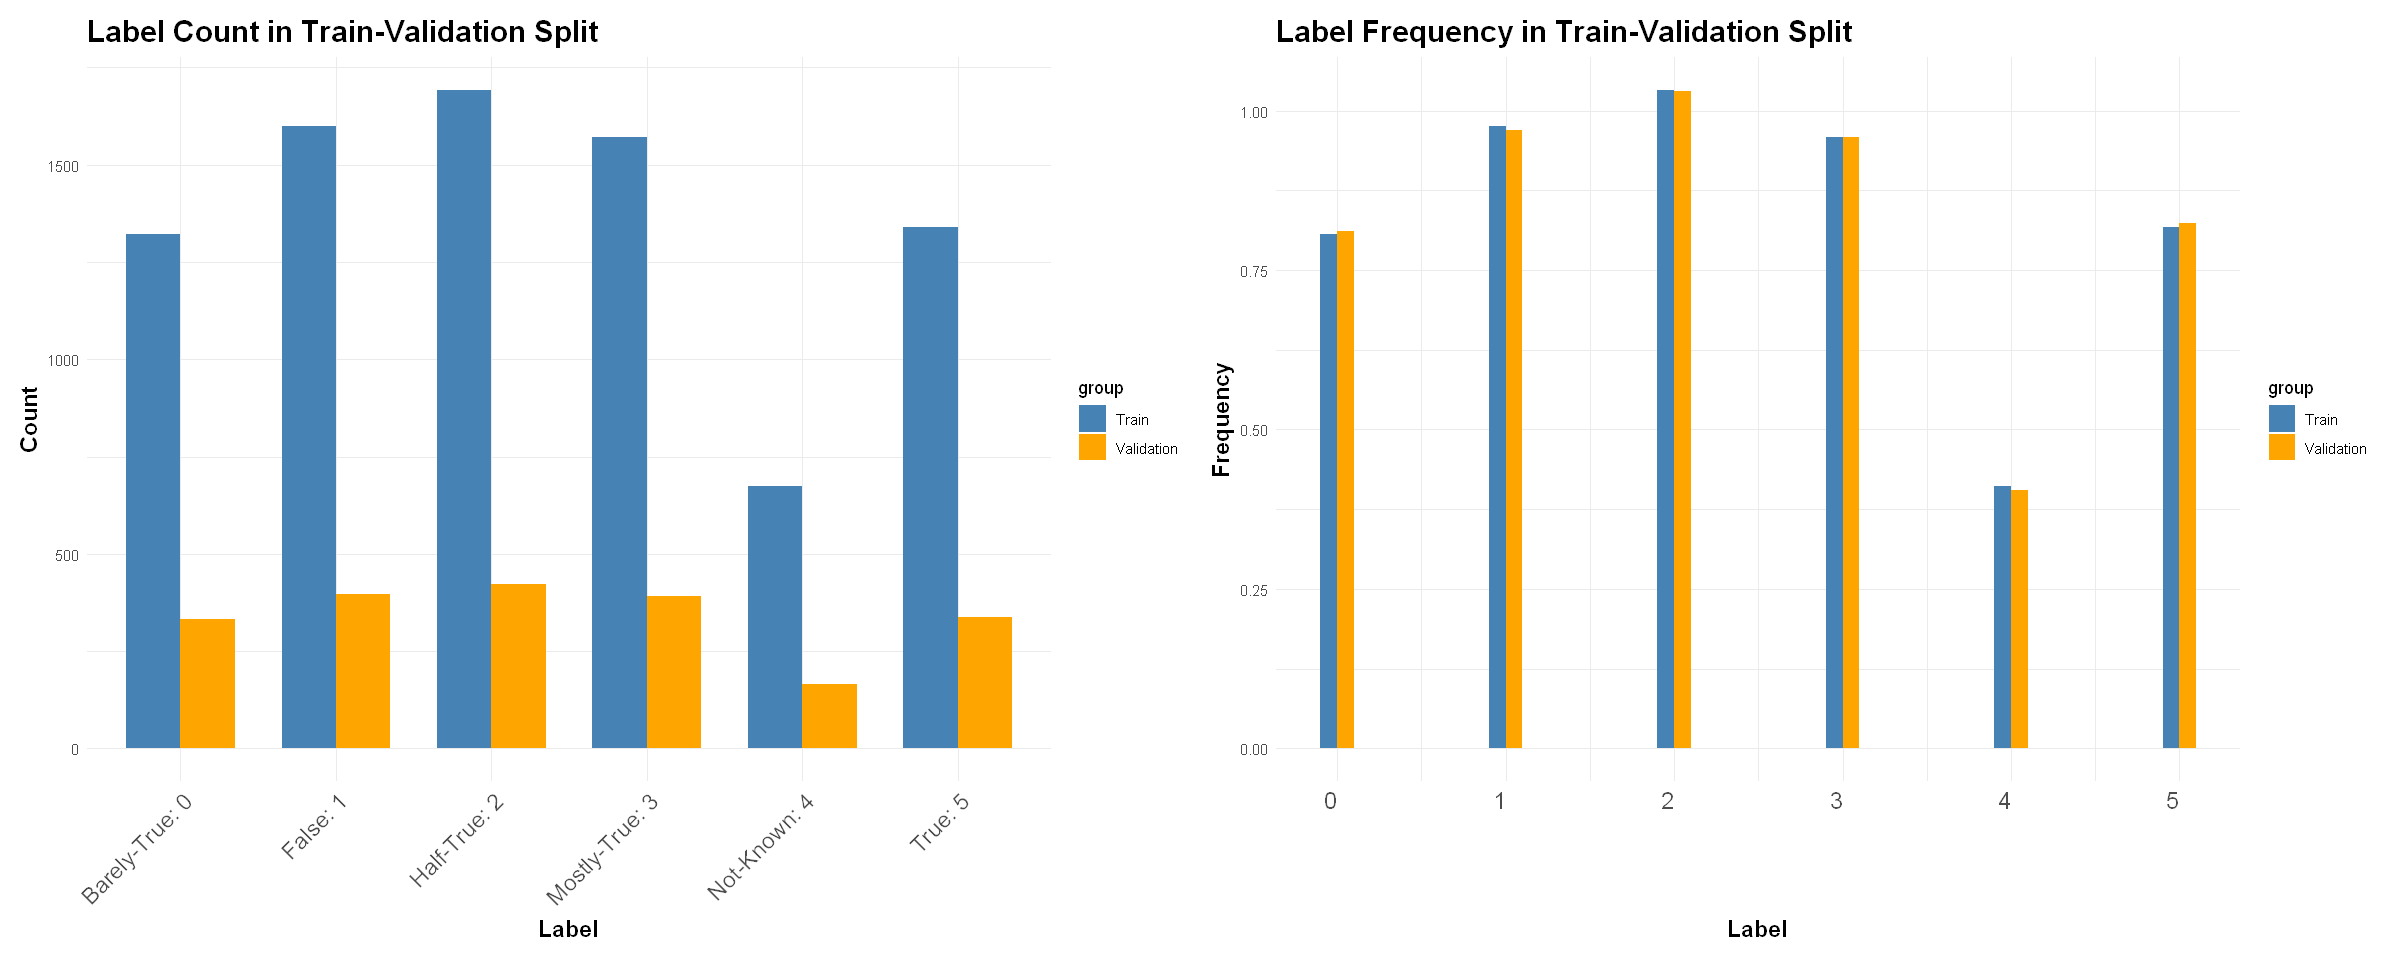

In [22]:
# Plot 1: Raw label counts
p1 <- ggplot(df, aes(x = Label, fill = group)) + 
  geom_bar(position = "dodge", width = 0.7) +
  theme_minimal() +
  labs(title = "Label Count in Train-Validation Split",
       x = "Label", y = "Count") +
  theme(
    axis.text.x = element_text(size = 14, angle = 45, hjust = 1),
    plot.title = element_text(size = 18, face = "bold"),
    axis.title.x = element_text(size = 14, face = "bold"),
    axis.title.y = element_text(size = 14, face = "bold")
  ) +
  scale_fill_manual(values = c("Train" = "steelblue", "Validation" = "orange"))

# Plot 2: Normalized frequency (density) of labels
p2 <- ggplot(df, aes(x = x, fill = group, y = after_stat(density))) + 
  geom_histogram(position = "dodge", stat = "bin", binwidth = 0.2) +  # binwidth = 1 for discrete labels
  theme_minimal() +
  labs(title = "Label Frequency in Train-Validation Split",
       x = "Label", y = "Frequency") +
  theme(
    axis.text.x = element_text(size = 14, hjust = 1),
    plot.title = element_text(size = 18, face = "bold"),
    axis.title.x = element_text(size = 14, face = "bold"),
    axis.title.y = element_text(size = 14, face = "bold")
  ) +
  scale_fill_manual(values = c("Train" = "steelblue", "Validation" = "orange"))

# Combine both plots side-by-side
combined_plot_bin <- p1 + p2 + plot_layout(ncol = 2)

# Display and save the combined plot
print(combined_plot_bin)
ggsave("Train_Validation_Split.png", plot = combined_plot_bin, width = 20, height = 6, dpi = 300)

## Preprocessing (Tokenize, Clean, Normalize)

We now prepare the text data for training the Naive Bayes classifier by performing the following steps:

* Convert text to lowercase
* Remove punctuation
* Tokenize text
* Remove stopwords (e.g., "the", "is", "and")
* Optional
    * Apply stemming (e.g., "running" $\rightarrow$ "run")
    * Or Apply Lemmatization (e.g., "running", "ran", "runs" → "run", 
                                    "better" → "good")

In [23]:
# Let us define a processing function
process_data <- function(data_var) {
  # Init variable
  result <- data_var$Text
  # Remove punctuation
  result <- gsub("[[:punct:] ]+", " ", result)
  # Remove caps
  result <- tolower(result)
  # Split by whitespaces
  result <- strsplit(result, split=" ") 
  result
}

In [24]:
# Process our train and validation data
trainProcessed <- process_data(trainData)
valProcessed <- process_data(validationData)

# How do the first rows of each dataset look like?
print(trainProcessed[1:3])

[[1]]
 [1] "says"      "the"       "annies"    "list"      "political" "group"    
 [7] "supports"  "third"     "trimester" "abortions" "on"        "demand"   

[[2]]
 [1] "hillary" "clinton" "agrees"  "with"    "john"    "mccain"  "by"     
 [8] "voting"  "to"      "give"    "george"  "bush"    "the"     "benefit"
[15] "of"      "the"     "doubt"   "on"      "iran"   

[[3]]
 [1] "health"      "care"        "reform"      "legislation" "is"         
 [6] "likely"      "to"          "mandate"     "free"        "sex"        
[11] "change"      "surgeries"  



### Numerical representation of text data

In [25]:
# We need to find a way to represent the terms found in the data in a numerical way
generate_numerical_mapping <- function(termsVar){
  # Get a single vector with all the terms
  flatTerms <- unlist(termsVar)
  # Get unique words and number of unique terms
  uniqueTerms <- unique(flatTerms)
  uniqueNum <- length(uniqueTerms)
  # Build mapping
  d <- data.frame(Term = uniqueTerms, Id = c(1:uniqueNum))
  d
}
numMapping <- generate_numerical_mapping(trainProcessed)

In [26]:
# View vocabulary size
cat("Vocabulary Size (Basic Processing):", nrow(numMapping), "\n")

Vocabulary Size (Basic Processing): 11164 


### Training of the Naive Bayes classifier

First, we need to train the prior of the algorithm. Even if we are only training one algorithm, let us build functions for an easy extension to other data.

Here, we define the prior of the model from the training data as follows:

$$P(c) = \frac{N_c}{\sum_{c'}N_{c'}}$$

where $N_c$ is the number of ocurrences of class $c$ in the training data.

In [27]:
# Function to train the prior
train_prior <- function (dataVar){
  # Get all the labels from the training data
  uniqueLabels <- unique(dataVar$Labels)
  # Get counts
  labelCounts <- table(dataVar$Labels)
  # Turn into dataframe
  labelData <- as.data.frame(labelCounts) 
  # Add column with relative frequency
  labelData$RelFreq <- labelData$Freq / nrow(dataVar)
  labelData
}

# Get prior from our training data
priorBayes <- train_prior(trainData)
priorBayes

Var1,Freq,RelFreq
<fct>,<int>,<dbl>
0,1322,0.16133756
1,1598,0.19502075
2,1692,0.20649256
3,1570,0.19160361
4,673,0.08213327
5,1339,0.16341225


Then, we need to train the likelihood of our model. Here, we will use Laplace smoothing to avoid issues generated by predicting on terms that were not observed during the training process. Therefore, the likelihood of a term $t$ belonging to class $c$ is defined by:

$$P(t|c) = \frac{T_{ct} + 1}{B + \sum_{t'\in V} T_{ct'}}$$

where $T_{ct}$ is the total number of occurrences of the term $t$ in documents of class $c$, and $B=|V|$ is the size of the vocabulary $V$ from the training data.

In order to deal with numerical accuracy, we can also calculate the log-likelihood, $\log(P(t|c))$.

In [28]:
# Function to train the log-likelihood of the model
train_log_likelihood <- function(dataVar, mappingVar, 
                                 processingFunc=process_data){
  # Get unique labels
  uniqueLabels <- unique(dataVar$Labels)

  # Init count matrix
  termsM <- matrix(0, nrow = nrow(mappingVar),
              ncol = length(uniqueLabels))
  
  # Get counts for each class
  for (i in uniqueLabels){
    # Get data in the same class
    labelData <- subset(dataVar, dataVar$Labels == i)
    # Process text
    processedText <- unlist(processingFunc(labelData))
    # Get counts for each term
    countsTerms <- as.data.frame(table(processedText))
    # Rename text column to match mapping data
    names(countsTerms)[names(countsTerms) == "processedText"] <- "Term"
    # Join the counts to the mapped ids
    mappedText <- right_join(mappingVar, countsTerms, by = "Term") 
    
    # Use mapping to update counts matrix
    labelIdx <- i+1
    termsM[mappedText$Id,labelIdx] = mappedText$Freq
  }
  # Get log-likelihood matrix
  topTerm <- termsM + 1
  M <- log(topTerm) - log(colSums(topTerm))
  M
}

# Get log-likelihood from the training data
logLikelihoodBayes <- train_log_likelihood(trainData, numMapping)

# Show some values
logLikelihoodBayes[1:10, 1:6]

-4.607331,-4.116294,-4.732089,-4.710820,-4.804108,-5.163871
-3.478313,-3.208393,-3.164823,-3.184583,-4.183264,-3.369909
-10.685332,-9.789114,-10.040550,-10.685332,-10.482262,-10.040550
-8.666081,-9.465603,-8.695953,-9.513379,-9.871068,-9.101418
-8.248791,-8.120383,-8.179676,-7.475601,-10.685332,-8.285037
-8.185127,-8.214096,-8.484773,-9.794565,-8.666081,-9.177920
-7.537823,-7.737965,-8.382747,-8.872824,-7.961109,-9.075894
-8.484773,-7.922763,-8.309406,-7.925158,-10.487712,-8.532550
-10.685332,-9.383649,-10.040550,-10.685332,-10.482262,-10.040550
-9.002553,-7.999265,-8.290488,-9.225697,-8.772455,-9.101418


### Making predictions with the Naive Bayes classifier

Here, we want to use our trained model to make predictions on the training and validation data. 

In [29]:
# Function to predict classes based on a trained model
naiveBayesPredict <- function(dataVar, priorVar, logLikeliVar, mappingVar, 
                              processingFunc=process_data){
  # Process text input
  processedText <- processingFunc(dataVar)
  # Init results 
  predClass <- 0*c(1:nrow(dataVar))
  # Operate separately for each input case
  for (i in c(1:nrow(dataVar))){
    # Get input data
    inputText <- processedText[i]
    # Get counts for each term and map using ids
    countsTerms <- as.data.frame(table(inputText))
    # Rename text column to match mapping data
    names(countsTerms)[names(countsTerms) == "inputText"] <- "Term"
    # Join the counts to the mapped ids
    mappedText <- merge(mappingVar, countsTerms, by = "Term") 
    # From the ids, get weights of each term for each class
    weightsTerms <- logLikeliVar[mappedText$Id,1:nrow(priorVar)]
    # Multiply by the amount of occurrences of each term to 
    # get log likelihood term
    logLikelyTerms <- colSums(mappedText$Freq*weightsTerms)
    # Add log-prior term to get the log-posterior
    logPosteriorTerms <- logLikelyTerms + log(priorVar$RelFreq)
    # Get predicted class with MAP
    predClass[i] = which.max(logPosteriorTerms) - 1
  }
  # Get the Id of the words present in the training vocabulary
  predClass
}

# Let's get the predictions for our training data
trainPreds <- naiveBayesPredict(trainData, priorBayes, logLikelihoodBayes, numMapping)

In [30]:
# Also the predictions for our validation data
validationPreds <- naiveBayesPredict(validationData, priorBayes, logLikelihoodBayes, numMapping)

### Measuring the performance of our model

In order to assess the performance of the model, we will use several metrics. First, for a visual comparison between ground-truth and predictions, let us use a confusion matrix. Since here we are dealing with multi-class data, we will estimate performance metrics for each class with a "one-versus-all" approach.

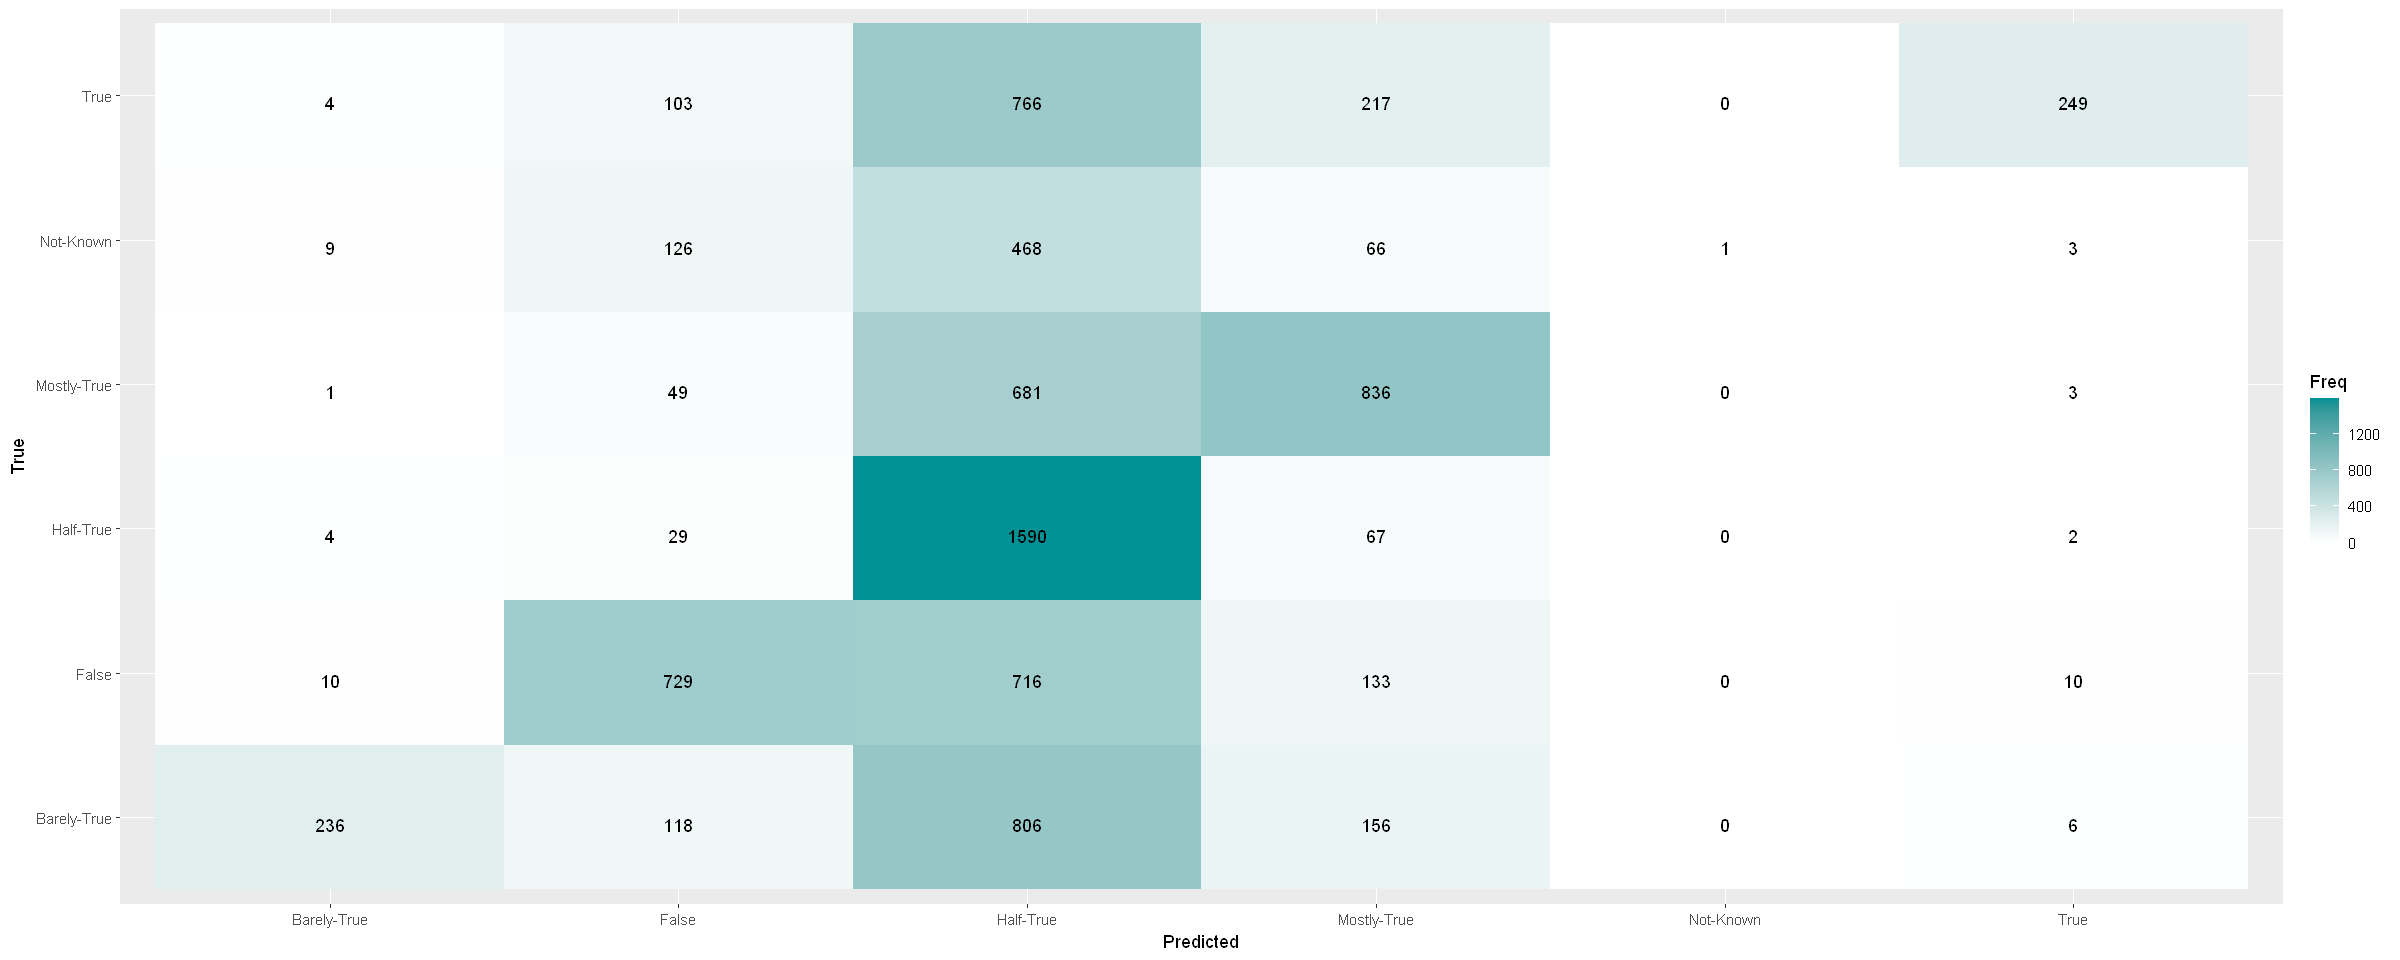

In [31]:
# Plot confusion matrix for train data
cmTrain <- confusionMatrix(factor(trainPreds), reference = factor(trainData$Labels), 
                dnn=c("Predicted", "True"))

# Convert the confusion matrix to a data frame
plt <- as.data.frame(cmTrain$table)

# Define our labels in order
plotLabels <- c("Barely-True","False","Half-True",
                "Mostly-True","Not-Known","True")

# Plot using ggplot2
ggplot(plt, aes(Predicted, True, fill = Freq)) +
  geom_tile() +
  geom_text(aes(label = Freq), vjust = 1) +
  scale_fill_gradient(low = "white", high = "#009194") +
  labs(x = "Predicted", y = "True") +
  scale_x_discrete(labels = plotLabels) +
  scale_y_discrete(labels = plotLabels)

In [32]:
# What is the specific performance on each class?
cmTrain$byClass

,Sensitivity,Specificity,Pos Pred Value,Neg Pred Value,Precision,Recall,F1,Prevalence,Detection Rate,Detection Prevalence,Balanced Accuracy
Class: 0,0.178517398,0.9959255,0.8939394,0.8630517,0.8939394,0.178517398,0.297604035,0.16133756,0.0288015621,0.0322186966,0.5872214
Class: 1,0.456195244,0.9355670,0.6317158,0.8765625,0.6317158,0.456195244,0.529796512,0.19502075,0.0889675372,0.1408347571,0.6958811
Class: 2,0.939716312,0.4713934,0.3162920,0.9677929,0.3162920,0.939716312,0.473284715,0.20649256,0.1940444227,0.6134976812,0.7055549
Class: 3,0.532484076,0.9035326,0.5667797,0.8907576,0.5667797,0.532484076,0.549096880,0.19160361,0.1020258726,0.1800097632,0.7180083
Class: 4,0.001485884,1.0000000,1.0000000,0.9179788,1.0000000,0.001485884,0.002967359,0.08213327,0.0001220405,0.0001220405,0.5007429
Class: 5,0.185959671,0.9964989,0.9120879,0.8623911,0.9120879,0.185959671,0.308933002,0.16341225,0.0303880888,0.0333170613,0.5912293


Warning message in levels(reference) != levels(data):
"longer object length is not a multiple of shorter object length"
Warning message in confusionMatrix.default(factor(validationPreds), reference = factor(validationData$Labels), :
"Levels are not in the same order for reference and data. Refactoring data to match."


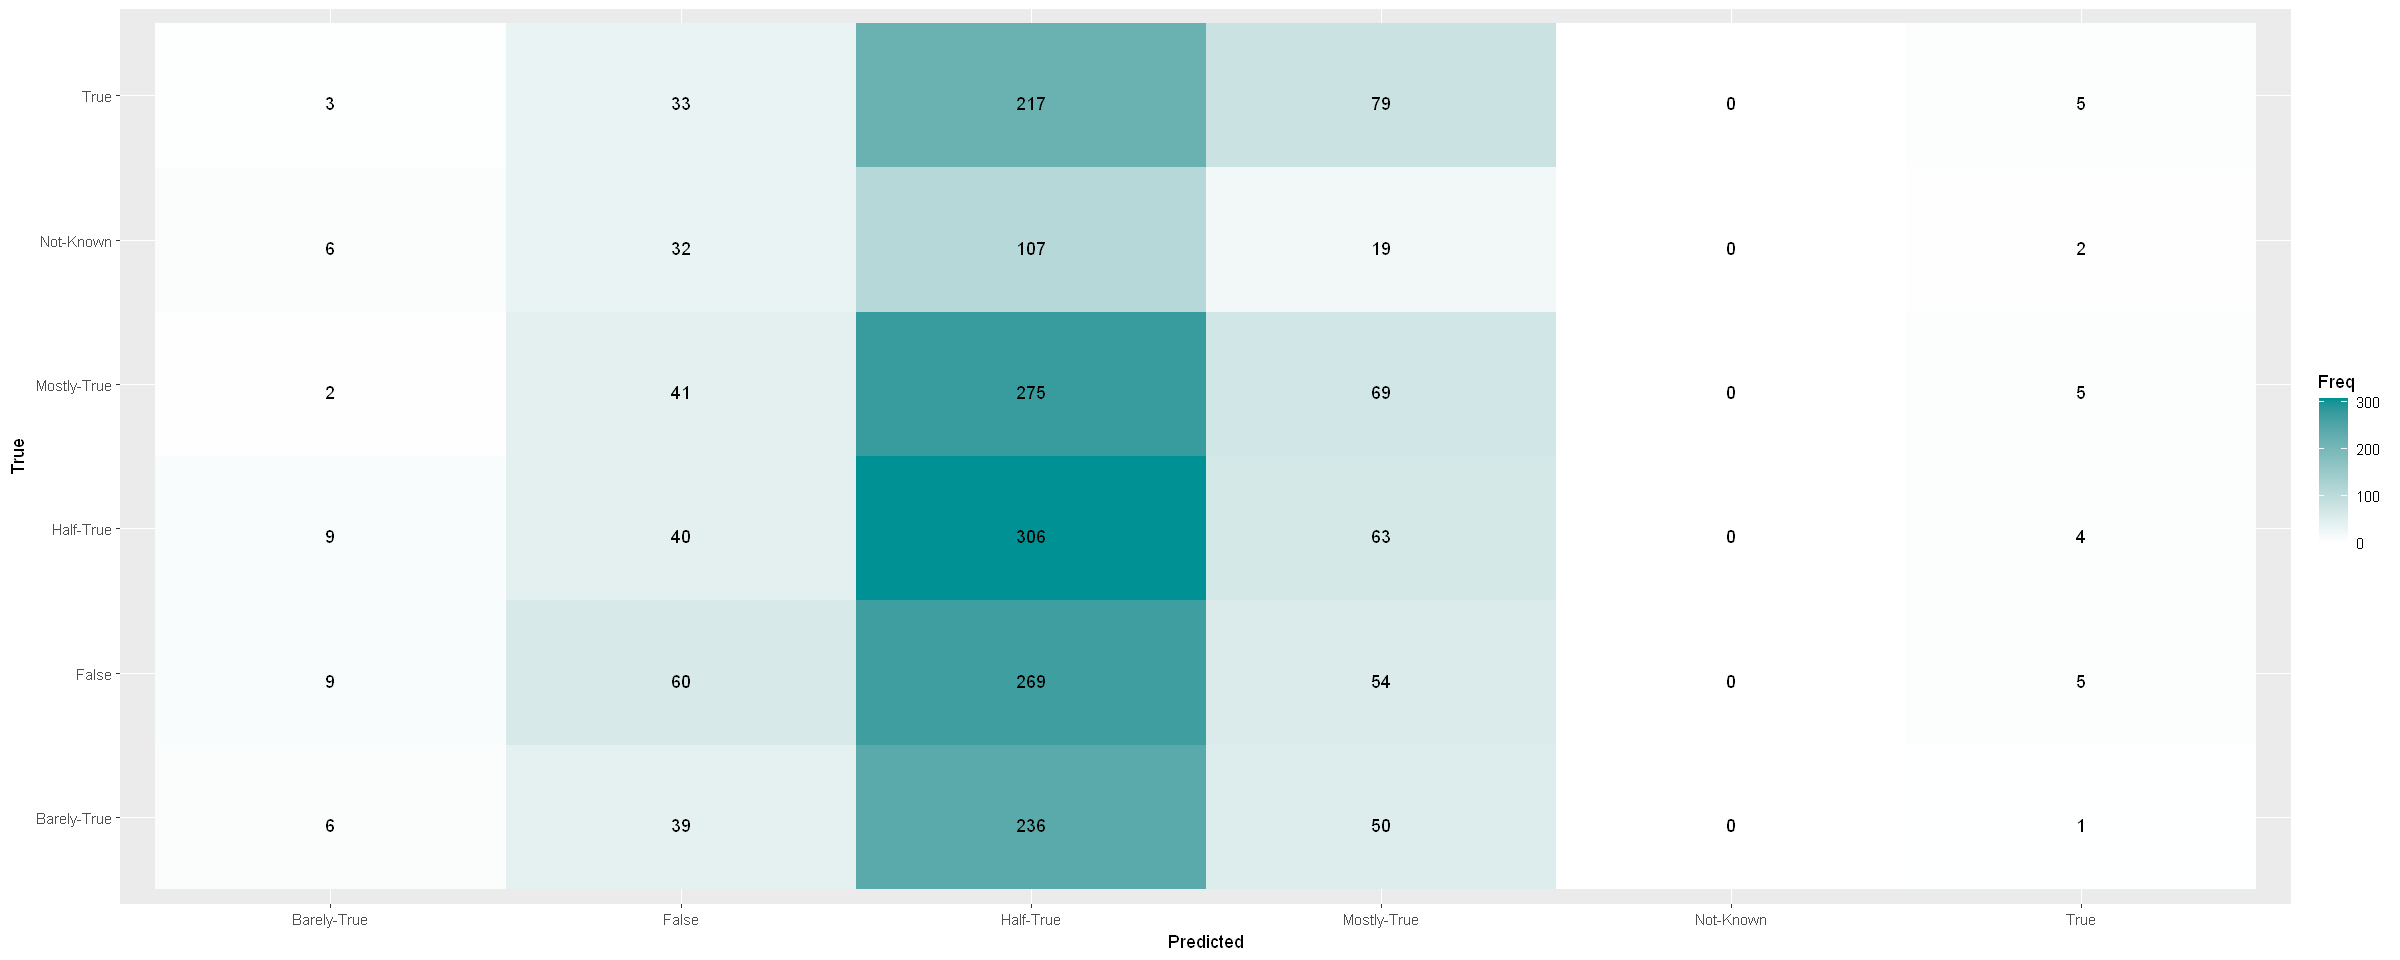

In [33]:
# Plot confusion matrix for validation data
cmValidation <- confusionMatrix(factor(validationPreds),
                                reference = factor(validationData$Labels), 
                                dnn=c("Predicted", "True"))

# Convert the confusion matrix to a data frame
plt <- as.data.frame(cmValidation$table)

# Define our labels in order
plotLabels <- c("Barely-True","False","Half-True",
                "Mostly-True","Not-Known","True")

# Plot using ggplot2
ggplot(plt, aes(Predicted, True, fill = Freq)) +
  geom_tile() +
  geom_text(aes(label = Freq), vjust = 1) +
  scale_fill_gradient(low = "white", high = "#009194") +
  labs(x = "Predicted", y = "True") +
  scale_x_discrete(labels = plotLabels) +
  scale_y_discrete(labels = plotLabels)

In [34]:
cmValidation$byClass

,Sensitivity,Specificity,Pos Pred Value,Neg Pred Value,Precision,Recall,F1,Prevalence,Detection Rate,Detection Prevalence,Balanced Accuracy
Class: 0,0.01807229,0.9830805,0.1714286,0.8378916,0.1714286,0.01807229,0.03269755,0.16226784,0.002932551,0.01710655,0.5005764
Class: 1,0.15113350,0.8878108,0.2448980,0.8128817,0.2448980,0.15113350,0.18691589,0.19403715,0.029325513,0.11974585,0.5194721
Class: 2,0.72511848,0.3201970,0.2170213,0.8176101,0.2170213,0.72511848,0.33406114,0.20625611,0.149560117,0.68914956,0.5226578
Class: 3,0.17602041,0.8397823,0.2065868,0.8113318,0.2065868,0.17602041,0.19008264,0.19159335,0.033724340,0.16324536,0.5079014
Class: 4,0.00000000,1.0000000,NaN,0.9188661,NA,0.00000000,NA,0.08113392,0.000000000,0.00000000,0.5000000
Class: 5,0.01483680,0.9900527,0.2272727,0.8359684,0.2272727,0.01483680,0.02785515,0.16471163,0.002443793,0.01075269,0.5024447


## Can these results be improven?

With regards to fake news detection, we may argue that sensitivity and precision are key performance metrics. This is because these metrics answer the following questions: 
- Sensitivity: Out of all the fake news we have, how many can we correctly identify as fake?
- Precision: Out of all the news we have classified as fake, how many of them are actually fake?

In both cases, a higher the score implies a better performance of the model. Certainly, accounting for more performance metrics would give a more robust assessment. However for now, let us focus solely on improving the sensitivity and precision for fake news detection. 

The first step is to build a pipeline that simply takes the input data and the necessary parameters, and performs the training and prediction procedure.


In [35]:
naiveBayesPipeline <- function(inputData, trainFraction, randomSeed, processingFunc){
  # Set random seed for reproducibility
  set.seed(randomSeed)
  
  # Draw a random, stratified sample including p percent of the data
  idx.train <- createDataPartition(y = inputData$Labels, 
                                   p = trainFraction, list = FALSE)
  # Training set with the given fraction p
  trainData <- inputData[idx.train, ]
  # Validation set with 1-p
  validationData <- inputData[-idx.train, ]
  
  # Process our train and validation data
  trainProcessed <- processingFunc(trainData)
  valProcessed <- processingFunc(validationData)
  
  # Remove instances with only 1-2 words
  trainKeepIds <- lapply(trainProcessed, function(x){length(x)}) > 2
  valKeepIds <- lapply(valProcessed, function(x){length(x)}) > 2
  
  trainProcessed <- trainProcessed[trainKeepIds]
  trainData <- trainData[trainKeepIds, 1:ncol(trainData)]
  valProcessed <- valProcessed[valKeepIds]
  validationData <- validationData[valKeepIds, 1:ncol(validationData)]
  
  # Generate numerical mapping for words in data
  numMapping <- generate_numerical_mapping(trainProcessed)
  
  # Get prior from our training data
  priorBayes <- train_prior(trainData)
  
  # Get log-likelihood from the training data
  logLikelihoodBayes <- train_log_likelihood(trainData, numMapping,
                                             processingFunc = processingFunc)
  
  # Let's get the predictions for our training data
  trainPreds <- naiveBayesPredict(trainData, priorBayes, 
                                  logLikelihoodBayes, numMapping,
                                  processingFunc = processingFunc)
  
  # Also the predictions for our validation data
  validationPreds <- naiveBayesPredict(validationData, priorBayes, 
                                       logLikelihoodBayes, numMapping, 
                                       processingFunc = processingFunc)
  
  
  # Get confusion matrix for train data
  cmTrain <- confusionMatrix(factor(trainPreds), reference = factor(trainData$Labels), 
                dnn=c("Predicted", "True"))
  cmTrain <- as.data.frame(cmTrain$byClass)
  
  # Get confusion matrix for validation data
  cmValidation <- confusionMatrix(factor(validationPreds), 
                                  reference = factor(validationData$Labels), 
                dnn=c("Predicted", "True"))
  cmValidation <- as.data.frame(cmValidation$byClass)
  
  results <- list(cmTrain, cmValidation)
  results
}

In [36]:
# Test our pipeline to check that everything works properly
naiveBayesPipeline(fakeNewsTrain, 0.8, 42, process_data)

Warning message in levels(reference) != levels(data):
"longer object length is not a multiple of shorter object length"
Warning message in confusionMatrix.default(factor(validationPreds), reference = factor(validationData$Labels), :
"Levels are not in the same order for reference and data. Refactoring data to match."


,Sensitivity,Specificity,Pos Pred Value,Neg Pred Value,Precision,Recall,F1,Prevalence,Detection Rate,Detection Prevalence,Balanced Accuracy
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Class: 0,0.170196672,0.9959213,0.8893281,0.8617343,0.8893281,0.170196672,0.285714286,0.16147551,0.0274825944,0.0309026505,0.5830590
Class: 1,0.455743879,0.9316045,0.6168224,0.8763195,0.6168224,0.455743879,0.524187726,0.19457677,0.0886771711,0.1437645047,0.6936742
Class: 2,0.940272028,0.4709052,0.3162920,0.9680380,0.3162920,0.940272028,0.473355165,0.20654696,0.1942103335,0.6140222304,0.7055886
Class: 3,0.521019108,0.9046396,0.5645273,0.8883942,0.5645273,0.521019108,0.541901292,0.19176744,0.0999144986,0.1769879077,0.7128293
Class: 4,0.001485884,1.0000000,1.0000000,0.9179086,1.0000000,0.001485884,0.002967359,0.08220349,0.0001221449,0.0001221449,0.5007429
Class: 5,0.191330344,0.9964958,0.9142857,0.8631592,0.9142857,0.191330344,0.316440049,0.16342983,0.0312690851,0.0342005619,0.5939131
,Sensitivity,Specificity,Pos Pred Value,Neg Pred Value,Precision,Recall,F1,Prevalence,Detection Rate,Detection Prevalence,Balanced Accuracy
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Class: 0,0.01807229,0.9801518,0.1500000,0.8374065,0.1500000,0.01807229,0.03225806,0.16234719,0.002933985,0.01955990,0.4991120


### Developing more advance processing functions

In [37]:
# Data processing with additional stopword removal
process_data_stopwords <- function(data_var) {
  # Load stopwords
  stopWords <- stop_words$word
  
  # Use only stopwords with length < 4
  stopWords <- stopWords[nchar(stopWords) < 4]
  
  # Init variable
  result <- data_var$Text
  # Remove punctuation
  result <- gsub("[[:punct:] ]+", " ", result)
  # Remove caps
  result <- tolower(result)
  # Split by whitespaces
  result <- strsplit(result, split=" ") 
  
  # Remove stopwords
  result <- lapply(result, function(words) {
    # Remove empty strings and stopwords
    words <- words[words != ""]
    words <- words[!words %in% stopWords]
    return(words)
  })
  
  result
}

# Basic preprocessing + stopword removal + stemming
process_data_stemmed <- function(data_var) {
  # Load stopwords
  stopWords <- stop_words$word
  
  # Use only stopwords with length < 4
  stopWords <- stopWords[nchar(stopWords) < 4]
  
  text <- tolower(data_var$Text)
  text <- gsub("[[:punct:]]+", " ", text)
  text <- gsub("\\s+", " ", text)
  tokens <- strsplit(text, split = " ")
  
  cleaned <- lapply(tokens, function(sentence) {
    words <- sentence[sentence != "" & !(sentence %in% stopWords)]
    words <- wordStem(words)  # stemming
    return(words)
  })
  
  return(cleaned)
}


# Basic preprocessing + stopword removal + lemmatization
process_data_lemmatized <- function(data_var) {
  # Load stopwords
  stopWords <- stop_words$word
  
  # Use only stopwords with length < 4
  stopWords <- stopWords[nchar(stopWords) < 4]
  
  text <- tolower(data_var$Text)
  text <- gsub("[[:punct:]]+", " ", text)
  text <- gsub("\\s+", " ", text)
  tokens <- strsplit(text, split = " ")
  
  cleaned <- lapply(tokens, function(sentence) {
    words <- sentence[sentence != "" & !(sentence %in% stopWords)]
    words <- lemmatize_words(words)  # lemmatization
    return(words)
  })
  
  return(cleaned)
}

In [38]:
trainProcessed_stopword <- process_data_stopwords(trainData)

print(trainProcessed_stopword[1:2])

[[1]]
 [1] "says"      "annies"    "list"      "political" "group"     "supports" 
 [7] "third"     "trimester" "abortions" "demand"   

[[2]]
 [1] "hillary" "clinton" "agrees"  "with"    "john"    "mccain"  "voting" 
 [8] "give"    "george"  "bush"    "benefit" "doubt"   "iran"   



In [39]:
numMapping_stopword <- generate_numerical_mapping(trainProcessed_stopword)
cat("Vocabulary Size (Basic + Stopword removal):", nrow(numMapping_stopword), "\n")

Vocabulary Size (Basic + Stopword removal): 11044 


In [40]:
trainProcessed_stemmed <- process_data_stemmed(trainData)

print(trainProcessed_stemmed[1:2])

[[1]]
 [1] "sai"     "anni"    "list"    "polit"   "group"   "support" "third"  
 [8] "trimest" "abort"   "demand" 

[[2]]
 [1] "hillari" "clinton" "agre"    "with"    "john"    "mccain"  "vote"   
 [8] "give"    "georg"   "bush"    "benefit" "doubt"   "iran"   



In [41]:
numMapping_stopword <- generate_numerical_mapping(trainProcessed_stemmed)
cat("Vocabulary Size (Basic + Stopword removal + stemming):", nrow(numMapping_stopword), "\n")

Vocabulary Size (Basic + Stopword removal + stemming): 7617 


In [42]:
trainProcessed_lemmatized <- process_data_lemmatized(trainData)

print(trainProcessed_lemmatized[1:2])

[[1]]
 [1] "say"       "annies"    "list"      "political" "group"     "support"  
 [7] "3"         "trimester" "abortion"  "demand"   

[[2]]
 [1] "hillary" "clinton" "agree"   "with"    "john"    "mccain"  "vote"   
 [8] "give"    "george"  "bush"    "benefit" "doubt"   "iran"   



In [43]:
numMapping_lemmatized <- generate_numerical_mapping(trainProcessed_lemmatized)
cat("Vocabulary Size (Basic + Stopword removal + lemmatization):", nrow(numMapping_lemmatized), "\n")

Vocabulary Size (Basic + Stopword removal + lemmatization): 8317 


In [44]:
# Run all different versions and save results for analysis
# Original processing
resultsOriginal <- naiveBayesPipeline(fakeNewsTrain, 0.8, 42, process_data)

# Stopword removal 
resultsStopwords <- naiveBayesPipeline(fakeNewsTrain, 0.8, 42, process_data_stopwords)

# Stemming + stopword removal
resultsStemStopwords <- naiveBayesPipeline(fakeNewsTrain, 0.8, 42, process_data_stemmed)

# Lemmatization + stopword removal
resultsLemmStopwords <- naiveBayesPipeline(fakeNewsTrain, 0.8, 42, process_data_lemmatized)

Warning message in levels(reference) != levels(data):
"longer object length is not a multiple of shorter object length"
Warning message in confusionMatrix.default(factor(validationPreds), reference = factor(validationData$Labels), :
"Levels are not in the same order for reference and data. Refactoring data to match."
Warning message in levels(reference) != levels(data):
"longer object length is not a multiple of shorter object length"
Warning message in confusionMatrix.default(factor(validationPreds), reference = factor(validationData$Labels), :
"Levels are not in the same order for reference and data. Refactoring data to match."


Saving 6.67 x 6.67 in image


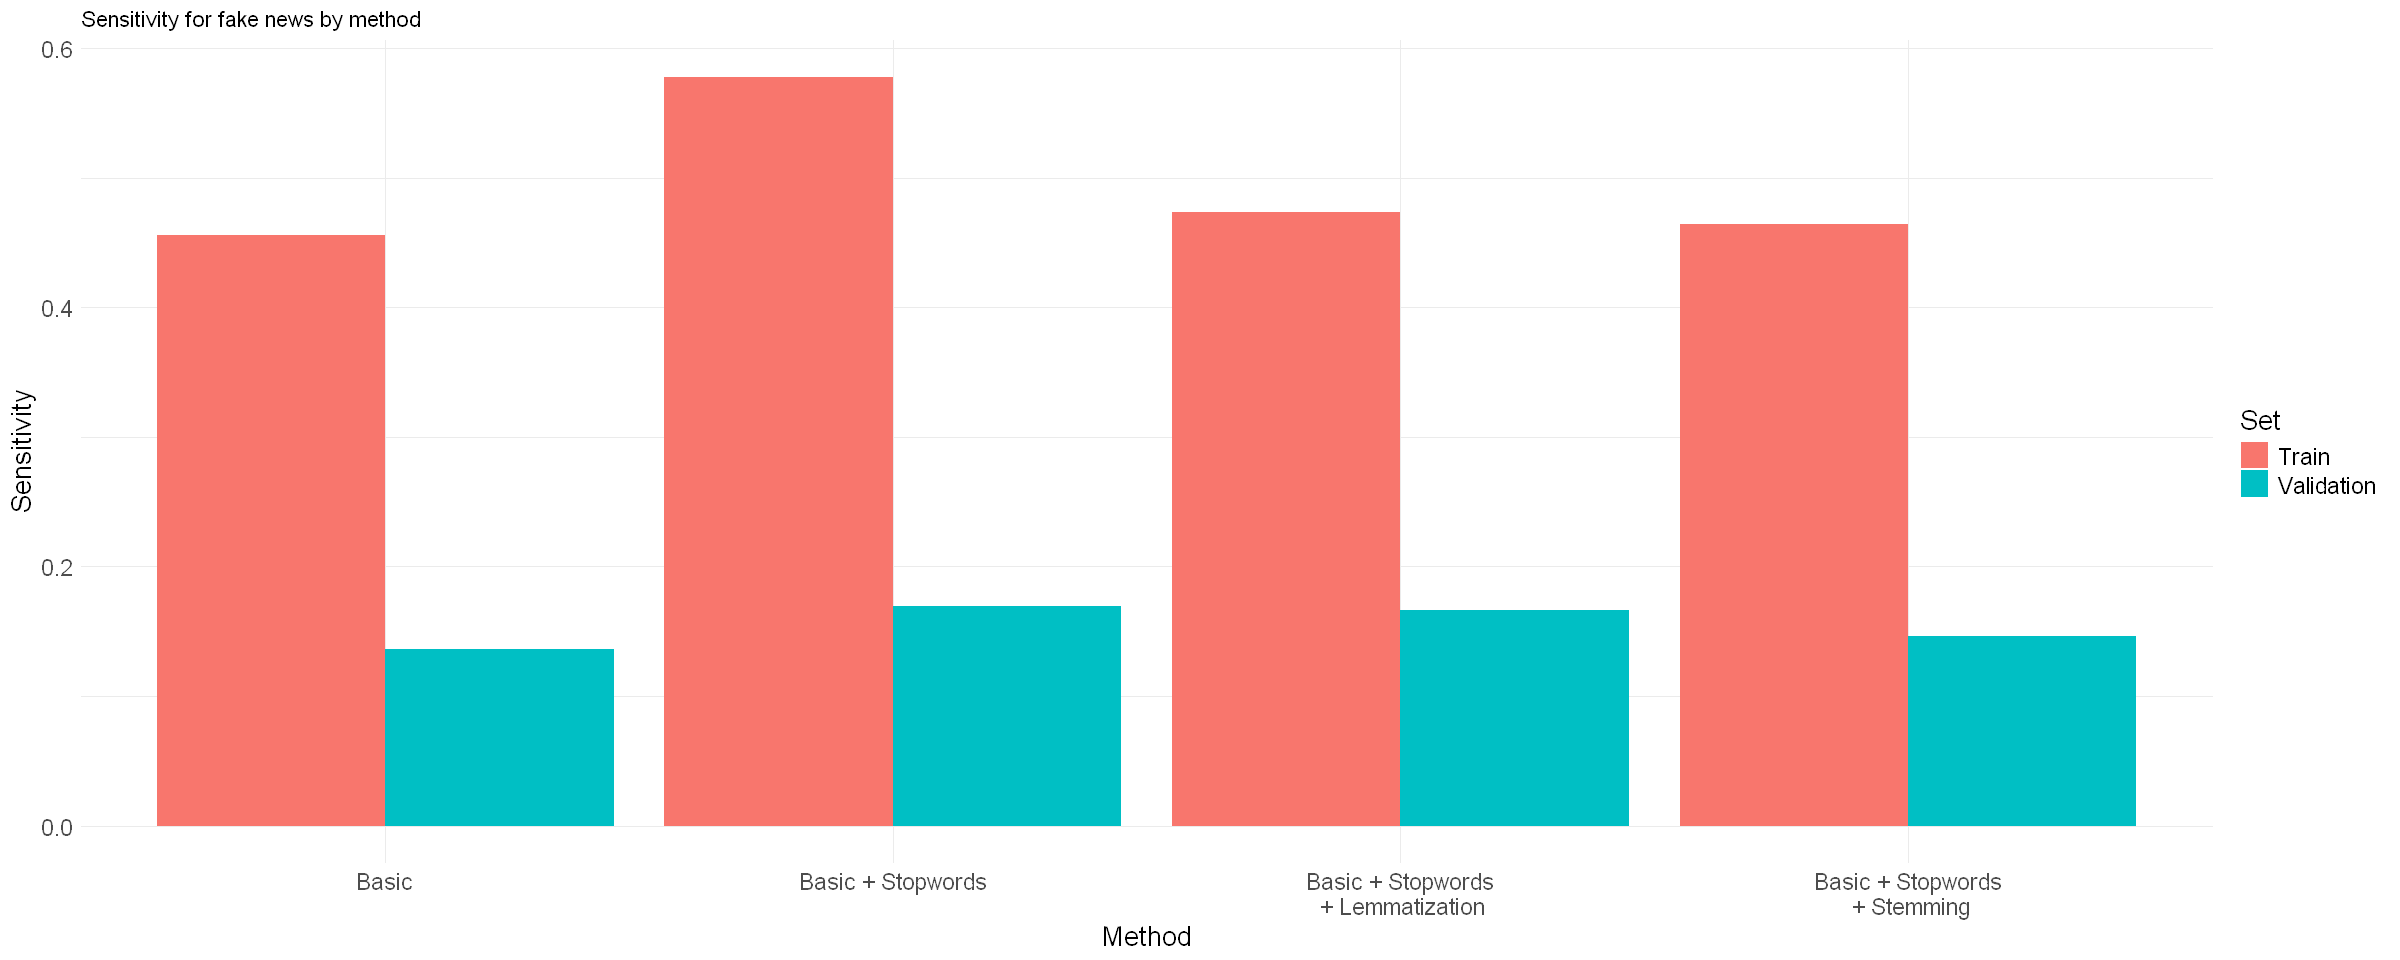

In [45]:
# Let us plot the sensitivity and precision of all the methods

methodNames <- c("Basic", "Basic + Stopwords", 
                 "Basic + Stopwords\n + Stemming", 
                 "Basic + Stopwords\n + Lemmatization")
# Group training and validation results
dfsTrain <- c(resultsOriginal[1], resultsStopwords[1],
              resultsStemStopwords[1], resultsLemmStopwords[1])
dfsVal <- c(resultsOriginal[2], resultsStopwords[2],
              resultsStemStopwords[2], resultsLemmStopwords[2])

# Get result metrics
trainSensitivities <- c(0,0,0,0)
trainPrecisions <- c(0,0,0,0)
valSensitivities <- c(0,0,0,0)
valPrecisions <- c(0,0,0,0)
for (i in c(1:4)){
  # Save train results
  dfTrain <- as.data.frame(dfsTrain[i])
  trainSensitivities[i] = dfTrain[2,]$Sensitivity
  trainPrecisions[i] = dfTrain[2,]$Precision
  
  # Save validation results
  dfVal <- as.data.frame(dfsVal[i])
  valSensitivities[i] = dfVal[2,]$Sensitivity
  valPrecisions[i] = dfVal[2,]$Precision
}

# Combine all results into a single data frame for plotting
plot_data <- data.frame(
  Method = rep(c(methodNames), times = 2),
  Set = rep(c("Train", "Validation"), each = 4),
  Sensitivity = c(trainSensitivities, valSensitivities),
  Precision = c(trainPrecisions, valPrecisions)
)

# Plot sensitivity for fake news
fontsize <- 16
ggplot(plot_data, aes(x = Method, y = Sensitivity, fill = Set)) +
  geom_bar(stat = "identity", position = position_dodge()) +
  labs(title = "Sensitivity for fake news by method",
       y = "Sensitivity", x = "Method") +
  theme_minimal() +
  theme(axis.text.x = element_text(size=fontsize-2, angle = 0, 
                                   hjust = 0.5),
        axis.text.y = element_text(size=fontsize-2),
        axis.title.x = element_text(size=fontsize),
        axis.title.y = element_text(size=fontsize),
        legend.title = element_text(size=fontsize),
        legend.text = element_text(size=fontsize-2))

ggsave("./fake_news_sensitivity_comparison_multi_class.png")

Saving 6.67 x 6.67 in image


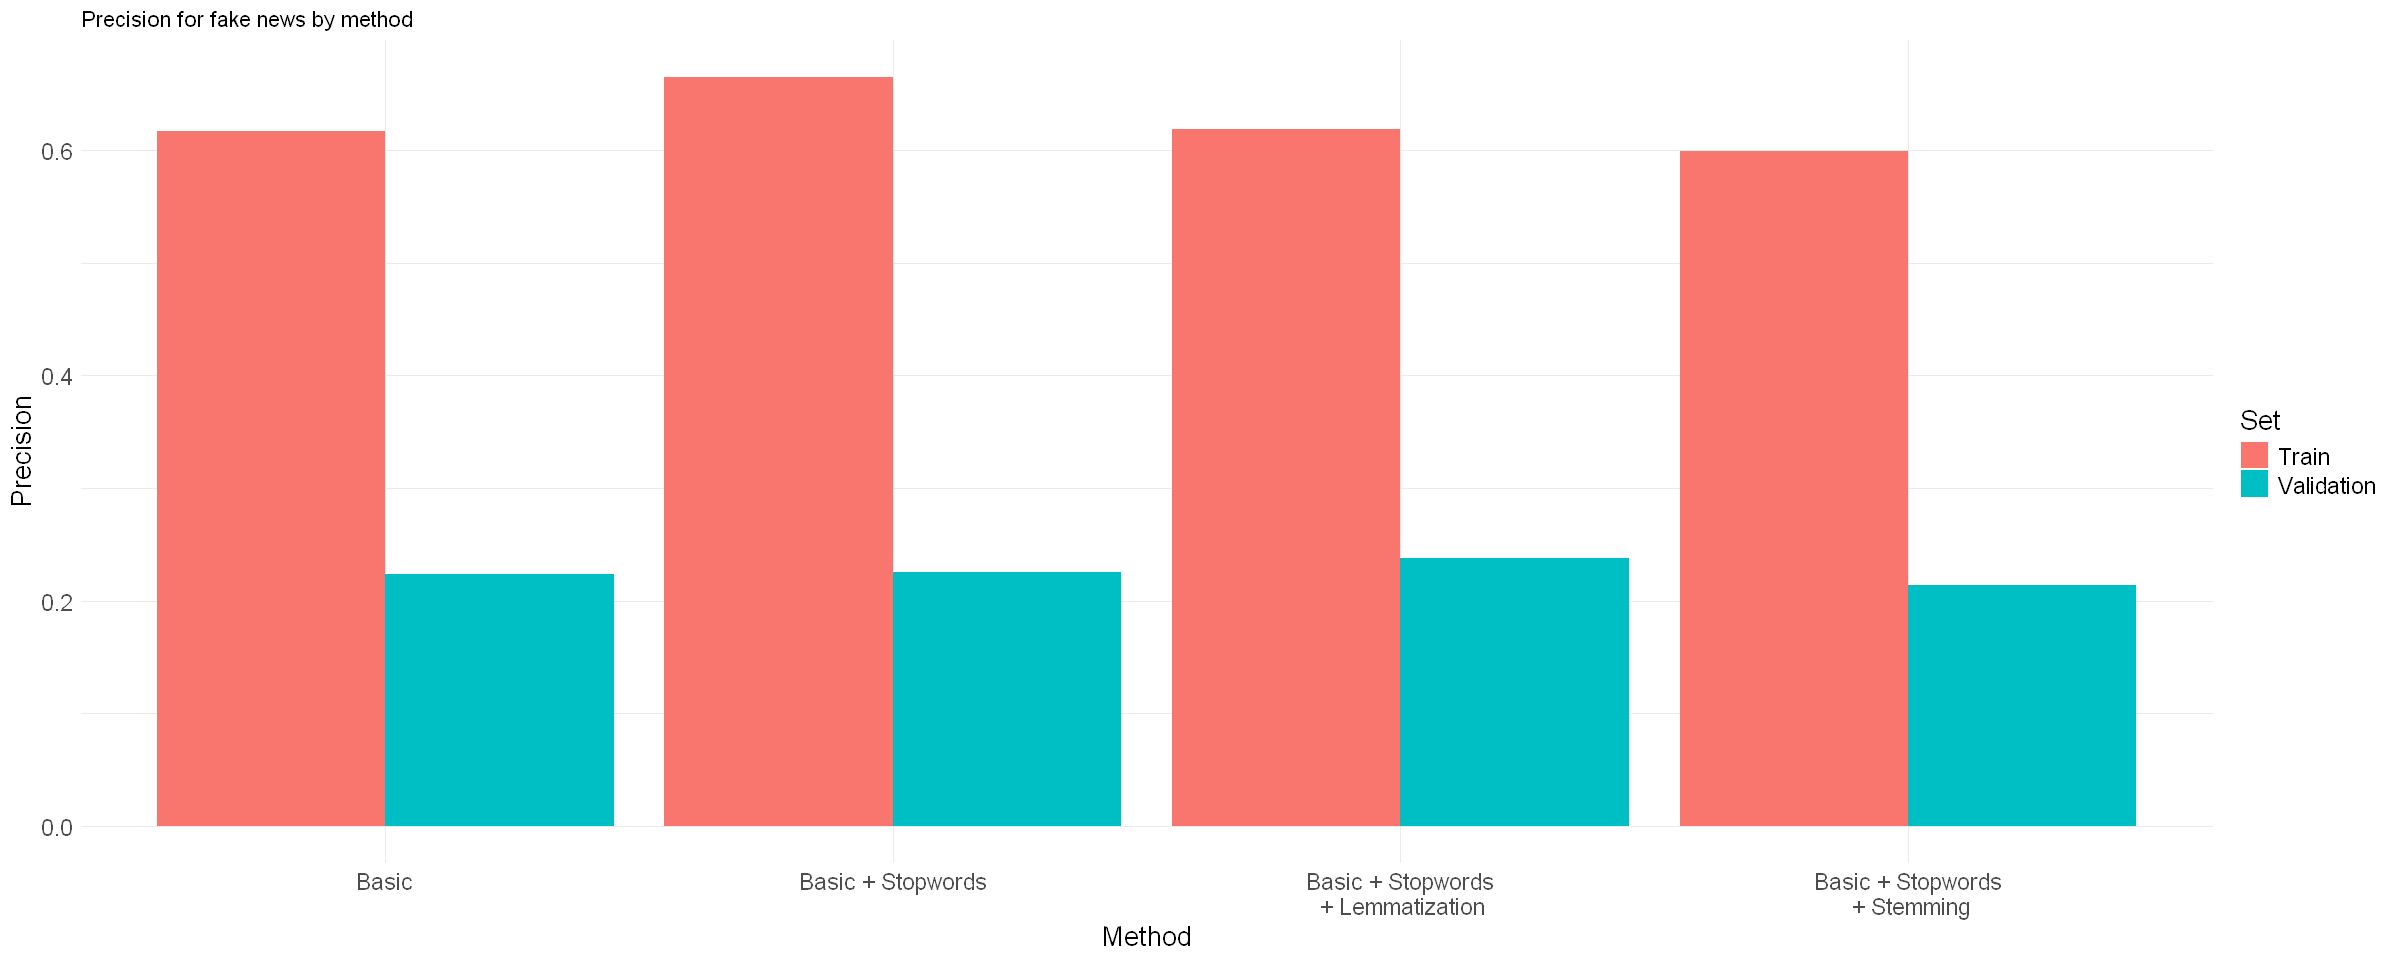

In [46]:
# Plot precision for fake news
ggplot(plot_data, aes(x = Method, y = Precision, fill = Set)) +
  geom_bar(stat = "identity", position = position_dodge()) +
  labs(title = "Precision for fake news by method",
       y = "Precision", x = "Method") +
  theme_minimal() +
  theme(axis.text.x = element_text(size=fontsize-2, angle = 0, 
                                   hjust = 0.5),
        axis.text.y = element_text(size=fontsize-2),
        axis.title.x = element_text(size=fontsize),
        axis.title.y = element_text(size=fontsize),
        legend.title = element_text(size=fontsize),
        legend.text = element_text(size=fontsize-2))
ggsave("./fake_news_precision_comparison_multi_class.png")

## Working with the Binary class data

In [47]:
# Run all different versions and save results for analysis
# Original processing
results2Original <- naiveBayesPipeline(trainData2, 0.8, 42, process_data)

# Stopword removal 
results2Stopwords <- naiveBayesPipeline(trainData2, 0.8, 42, process_data_stopwords)

# Stemming + stopword removal
results2StemStopwords <- naiveBayesPipeline(trainData2, 0.8, 42, process_data_stemmed)

# Lemmatization + stopword removal
results2LemmStopwords <- naiveBayesPipeline(trainData2, 0.8, 42, process_data_lemmatized)

Saving 6.67 x 6.67 in image


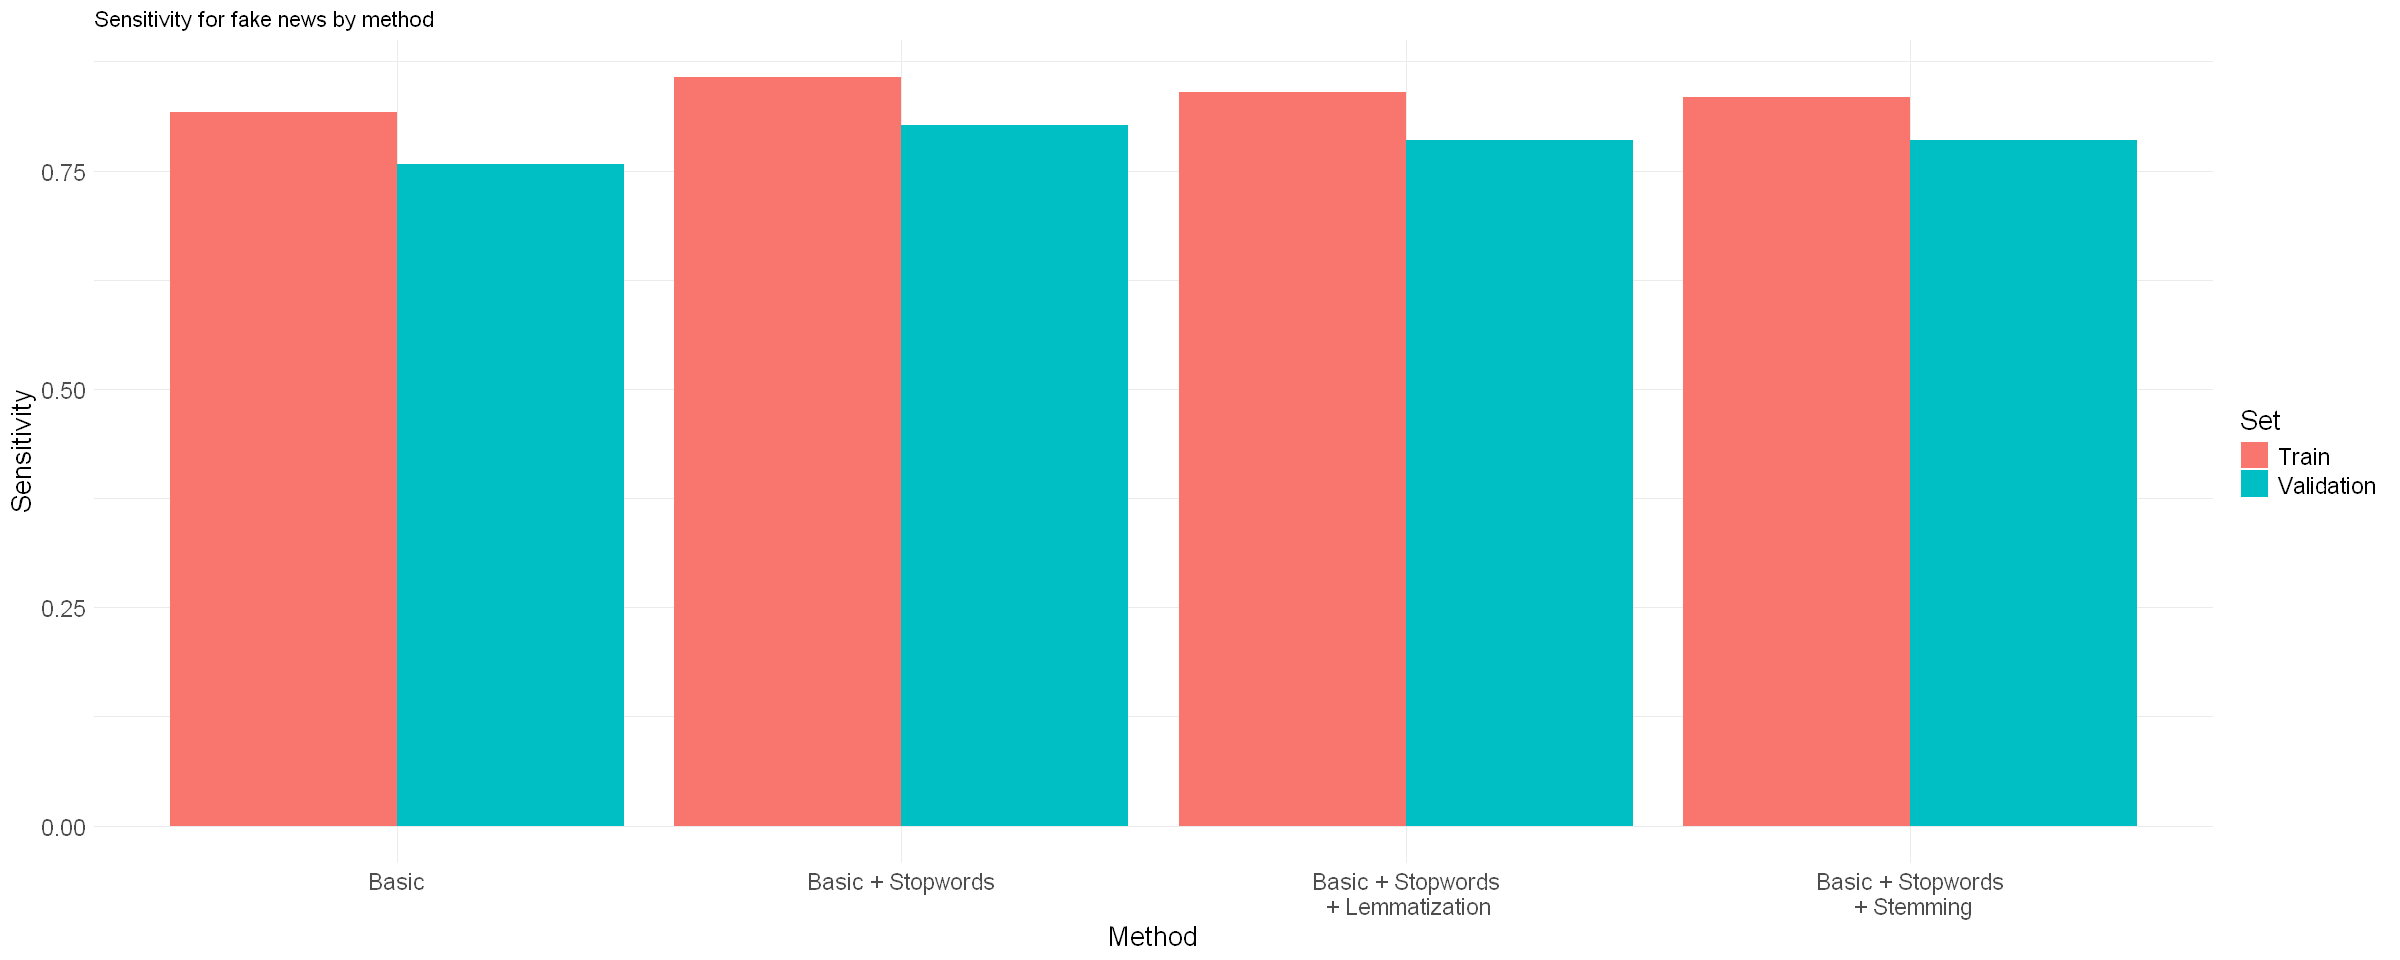

In [48]:
# Let us plot the sensitivity and precision of all the methods

methodNames <- c("Basic", "Basic + Stopwords", 
                 "Basic + Stopwords\n + Stemming", 
                 "Basic + Stopwords\n + Lemmatization")
# Group training and validation results
dfsTrain2 <- c(results2Original[1], results2Stopwords[1],
              results2StemStopwords[1], results2LemmStopwords[1])
dfsVal2 <- c(results2Original[2], results2Stopwords[2],
              results2StemStopwords[2], results2LemmStopwords[2])

# Get result metrics
trainSensitivities2 <- c(0,0,0,0)
trainPrecisions2 <- c(0,0,0,0)
valSensitivities2 <- c(0,0,0,0)
valPrecisions2 <- c(0,0,0,0)
for (i in c(1:4)){
  # Save train results
  dfTrain <- as.data.frame(dfsTrain2[i])
  trainSensitivities2[i] = dfTrain[1,]
  trainPrecisions2[i] = dfTrain[5,]
  
  # Save validation results
  dfVal <- as.data.frame(dfsVal2[i])
  valSensitivities2[i] = dfVal[1,]
  valPrecisions2[i] = dfVal[5,]
}

# Combine all results into a single data frame for plotting
plot_data2 <- data.frame(
  Method = rep(c(methodNames), times = 2),
  Set = rep(c("Train", "Validation"), each = 4),
  Sensitivity = c(trainSensitivities2, valSensitivities2),
  Precision = c(trainPrecisions2, valPrecisions2)
)

# Plot sensitivity for fake news
fontsize <- 16
ggplot(plot_data2, aes(x = Method, y = Sensitivity, fill = Set)) +
  geom_bar(stat = "identity", position = position_dodge()) +
  labs(title = "Sensitivity for fake news by method",
       y = "Sensitivity", x = "Method") +
  theme_minimal() +
  theme(axis.text.x = element_text(size=fontsize-2, angle = 0, 
                                   hjust = 0.5),
        axis.text.y = element_text(size=fontsize-2),
        axis.title.x = element_text(size=fontsize),
        axis.title.y = element_text(size=fontsize),
        legend.title = element_text(size=fontsize),
        legend.text = element_text(size=fontsize-2))

ggsave("./fake_news_sensitivity_comparison_binary.png")

Saving 6.67 x 6.67 in image


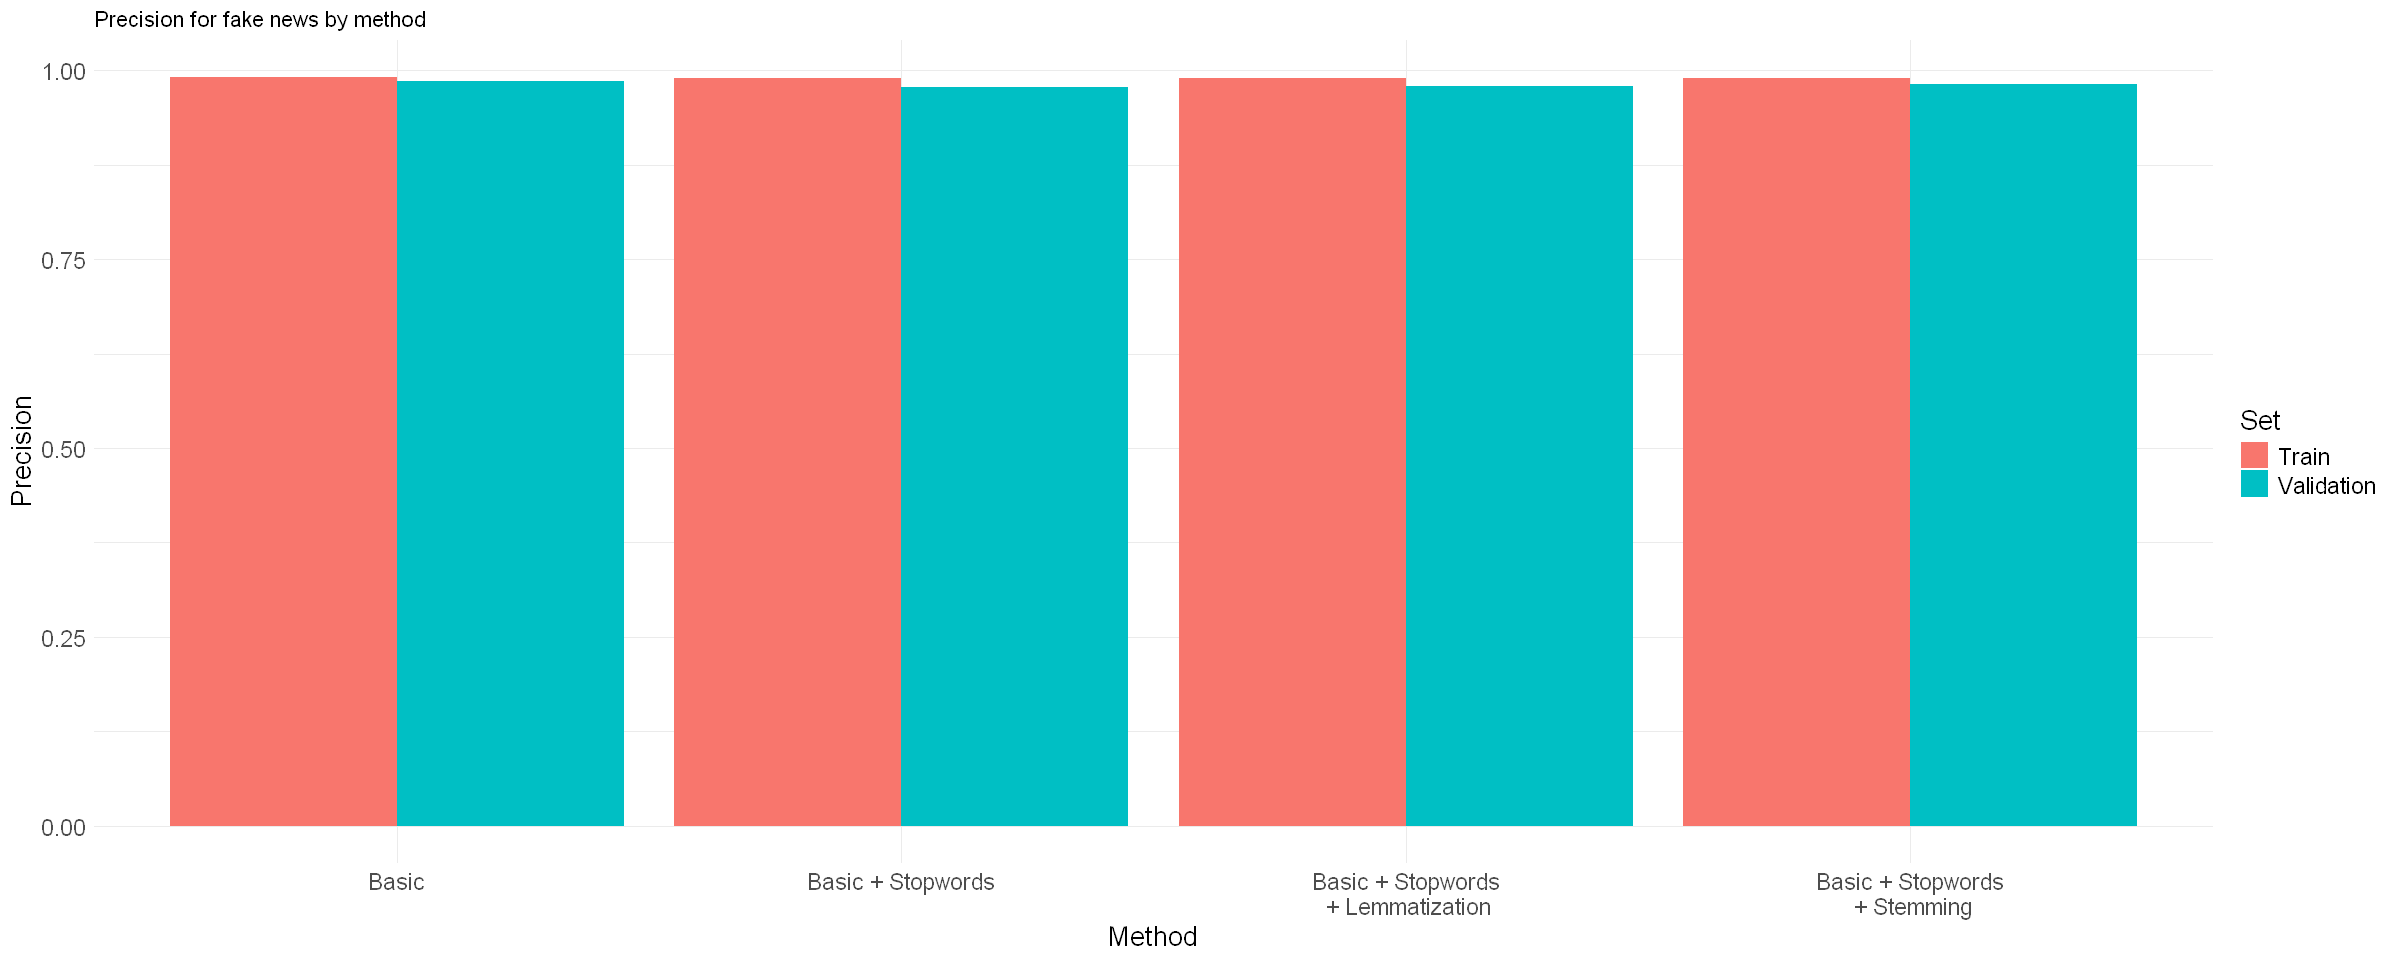

In [49]:
# Plot precision for fake news
ggplot(plot_data2, aes(x = Method, y = Precision, fill = Set)) +
  geom_bar(stat = "identity", position = position_dodge()) +
  labs(title = "Precision for fake news by method",
       y = "Precision", x = "Method") +
  theme_minimal() +
  theme(axis.text.x = element_text(size=fontsize-2, angle = 0, 
                                   hjust = 0.5),
        axis.text.y = element_text(size=fontsize-2),
        axis.title.x = element_text(size=fontsize),
        axis.title.y = element_text(size=fontsize),
        legend.title = element_text(size=fontsize),
        legend.text = element_text(size=fontsize-2))
ggsave("./fake_news_precision_comparison_binary.png")